# Specdiff Results

This notebook mirrors the analysis-ready files from the private Hugging Face dataset [`marcellobullo/tree-specdiff-results`](https://huggingface.co/datasets/marcellobullo/tree-specdiff-results) into the repository-level `results/` directory, then loads them with pandas.

The Hub repository is an artifact tree rather than a single tabular dataset, so `huggingface_hub.snapshot_download` is the right interface: it preserves the directory layout, handles authentication and LFS, and can pin a revision. By default, the notebook downloads only JSON and CSV files. This is roughly 2 MiB locally; the full snapshot is about 6.7 GiB because it also contains `.pt` tensors and image grids.

Because the dataset is private, the machine must already be authenticated (for example with `hf auth login` or an `HF_TOKEN` environment variable).

In [3]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from huggingface_hub import HfApi, snapshot_download

%config InlineBackend.figure_format = 'retina'

# pd.set_option("display.max_columns", 100)

REPO_ROOT = Path("./").resolve().parent
RESULTS_DIR = REPO_ROOT / "results"
HF_REPO_ID = "marcellobullo/tree-specdiff-results"
REVISION = "main"

# Keep this False for pandas analysis. True also downloads tensors, images, and logs.
DOWNLOAD_FULL_ARTIFACTS = False
ANALYSIS_PATTERNS = ["results/**/*.json", "results/**/*.csv"]

print(f"Repository root: {REPO_ROOT}")
print(f"Local results:   {RESULTS_DIR}")

Repository root: /home/mb1921/specdiff
Local results:   /home/mb1921/specdiff/results


## Download into the checkout
Re-running this cell is incremental. 

Set `DOWNLOAD_FULL_ARTIFACTS = True` only when plots need the saved tensors or grids; that currently expands the download from about 2 MiB to about 6.7 GiB.

In [10]:
#api = HfApi()
#repo_info = api.dataset_info(HF_REPO_ID, revision=REVISION, files_metadata=True)

#download_patterns = ["results/**"] if DOWNLOAD_FULL_ARTIFACTS else ANALYSIS_PATTERNS
#snapshot_download(
#    repo_id=HF_REPO_ID,
#    repo_type="dataset",
#    revision=repo_info.sha,
#    local_dir=REPO_ROOT,
#    allow_patterns=download_patterns,
#)
#
#local_json = sorted(RESULTS_DIR.rglob("*.json"))
#local_csv = sorted(RESULTS_DIR.rglob("*.csv"))
#print(f"Downloaded/available locally: {len(local_json):,} JSON + {len(local_csv):,} CSV files")

## Image experiments (`edm` and `sd3`)

Each completed image run has one `meta.json`. `pandas.json_normalize` flattens nested dictionaries such as `run_signature.config` while retaining list-valued fields (for example per-trajectory rounds) as Python objects. Path-derived columns make the experiment hierarchy explicit.

In [57]:
def load_image_meta(path: Path) -> dict:
    payload = json.loads(path.read_text())
    relative = path.relative_to(RESULTS_DIR)
    parts = relative.parts
    method_dir = path.parent.name
    row = {
        "source_path": relative.as_posix(),
        "family": parts[0],
        "dataset": parts[1],
        "experiment": parts[2],
        "epsilon_dir": next((part for part in parts if part.startswith("eps")), None),
        "cell": path.parent.parent.name if method_dir in {"d-grs", "rmc"} else None,
        "method_dir": method_dir,
    }
    row.update(pd.json_normalize(payload, sep=".").iloc[0].to_dict())
    return row

meta_paths = sorted([
    path
    for family in ("edm", "sd3")
    for path in RESULTS_DIR.glob(f"{family}/**/meta.json")
])
#meta_paths = sorted(RESULTS_DIR.glob("{edm,sd3}/**/meta.json"))
image_results = pd.DataFrame(load_image_meta(path) for path in meta_paths)
image_results["match"] = image_results["run_signature.config.match"].fillna(
    image_results["match"]
)
image_results["evaluate_leaves"] = image_results["sampler.evaluate_leaves"]
image_results["prefetch"] = image_results["sampler.prefetch"]

image_results.rename(
    columns={
        "branching": "K",
        "lookahead": "L",
        "proposal_budget": "B",
        "network": "denoiser_model"
    },
    inplace=True
)

def compute_verification_budget(row):
    K = row['K']
    L = row['L']
    return (K ** L - 1) // (K - 1) if K > 1 else L
image_results["allocated_verification_budget"] = image_results.apply(compute_verification_budget, axis=1)

def compute_B_budget(row):
    K = row['K']
    L = row['L']
    return (K ** (L+1) - 1) // (K - 1) if K > 1 else L
image_results["allocated_B_budget"] = image_results.apply(compute_B_budget, axis=1)

# compute the speedup as the mean of rounds_per_trajectory divided by num_samples
image_results["speedup_mean"] = image_results.apply(
    lambda row: np.mean(row["speculative_steps"]/ np.asarray(row["metric_totals.rounds_per_trajectory"], dtype=float)),
    axis=1,
)
image_results["speedup_std"] = image_results.apply(
    lambda row: np.std(row["speculative_steps"]/ np.asarray(row["metric_totals.rounds_per_trajectory"], dtype=float)),
    axis=1,
)

image_results["acceptance_rate"] = image_results["metric_totals.accepted_levels"]/ image_results["metric_totals.verified_levels"]

image_columns = [
    "family", "dataset", "experiment", "denoiser_model",
    "rule", "match", "prefetch", "evaluate_leaves", "K", "L", "B", "verification_budget", "eps", "num_samples", "speculative_steps", "total_steps", "shift", "conditional", "num_classes", "source_path", "seed",
    "target_calls", "speedup_mean", "speedup_std", "acceptance_rate", 
    "allocated_verification_budget", "allocated_B_budget"
]

image_results.drop(columns=[col for col in image_results.columns if col not in image_columns], inplace=True)

display(image_results)
print([str(col) for col in image_results.columns])

image_run_counts = (
    image_results.groupby(["family", "dataset", "match", "rule"], dropna=False)
    .size()
    .rename("runs")
    .to_frame()
)

display(image_run_counts)

,source_path,family,dataset,experiment,rule,denoiser_model,num_samples,total_steps,speculative_steps,eps,...,conditional,num_classes,acceptance_rate,target_calls,evaluate_leaves,prefetch,allocated_verification_budget,allocated_B_budget,speedup_mean,speedup_std
0,edm/cifar10/cifar10_n500_leaves_match-budget/e...,edm,cifar10,cifar10_n500_leaves_match-budget,d-grs,/home/mb1921/specdiff/edm/edm-cifar10-32x32-co...,500,100,98,0.1,...,True,10.0,0.670265,184,True,nearest,7,15,2.362579,0.071258
1,edm/cifar10/cifar10_n500_leaves_match-budget/e...,edm,cifar10,cifar10_n500_leaves_match-budget,rmc,/home/mb1921/specdiff/edm/edm-cifar10-32x32-co...,500,100,98,0.1,...,True,10.0,0.592347,724,True,nearest,7,15,2.455890,0.119361
2,edm/cifar10/cifar10_n500_leaves_match-budget/e...,edm,cifar10,cifar10_n500_leaves_match-budget,d-grs,/home/mb1921/specdiff/edm/edm-cifar10-32x32-co...,500,100,98,0.1,...,True,10.0,0.628796,1330,True,nearest,31,63,2.611963,0.120905
3,edm/cifar10/cifar10_n500_leaves_match-budget/e...,edm,cifar10,cifar10_n500_leaves_match-budget,rmc,/home/mb1921/specdiff/edm/edm-cifar10-32x32-co...,500,100,98,0.1,...,True,10.0,0.591898,2801,True,nearest,31,63,2.452690,0.117923
4,edm/cifar10/cifar10_n500_leaves_match-budget/e...,edm,cifar10,cifar10_n500_leaves_match-budget,d-grs,/home/mb1921/specdiff/edm/edm-cifar10-32x32-co...,500,100,98,0.1,...,True,10.0,0.661918,1720,True,nearest,40,121,2.621838,0.106288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,sd3/coco2014/coco2014_n100_match-verification/...,sd3,coco2014,coco2014_n100_match-verification,d-grs,stabilityai/stable-diffusion-3.5-medium,100,50,48,0.8,...,NaN,NaN,0.117708,548,False,nearest,7,43,1.134740,0.042699
146,sd3/coco2014/coco2014_n100_match-verification/...,sd3,coco2014,coco2014_n100_match-verification,rmc,stabilityai/stable-diffusion-3.5-medium,100,50,48,0.8,...,NaN,NaN,0.106667,555,False,nearest,7,43,1.121107,0.044181
147,sd3/coco2014/coco2014_n100_match-verification/...,sd3,coco2014,coco2014_n100_match-verification,d-grs,stabilityai/stable-diffusion-3.5-medium,100,50,48,0.8,...,NaN,NaN,0.143542,4211,False,nearest,43,259,1.170564,0.059567
148,sd3/coco2014/coco2014_n100_match-verification/...,sd3,coco2014,coco2014_n100_match-verification,rmc,stabilityai/stable-diffusion-3.5-medium,100,50,48,0.8,...,NaN,NaN,0.109375,4375,False,nearest,43,259,1.124794,0.047682


['source_path', 'family', 'dataset', 'experiment', 'rule', 'denoiser_model', 'num_samples', 'total_steps', 'speculative_steps', 'eps', 'shift', 'K', 'L', 'match', 'B', 'verification_budget', 'seed', 'conditional', 'num_classes', 'acceptance_rate', 'target_calls', 'evaluate_leaves', 'prefetch', 'allocated_verification_budget', 'allocated_B_budget', 'speedup_mean', 'speedup_std']


runs
family dataset  match        rule        
edm    cifar10  budget       d-grs     12
                             rmc       12
                             target     3
                verification d-grs     12
                             rmc       12
                             target     3
       ffhq     budget       d-grs     12
                             rmc       12
                             target     3
                verification d-grs     12
                             rmc       12
                             target     3
sd3    coco2014 budget       d-grs     10
                             rmc       10
                verification d-grs     10
                             rmc       10
                             target     2

In [ ]:
# # Return all the uniwue pairs (K,L) 
# image_results[
#     (image_results["family"] == "edm") & 
#     (image_results["match"]=="budget")
# ][["K", "L", "allocated_B_budget", "allocated_verification_budget"]].drop_duplicates()

,K,L,allocated_B_budget,allocated_verification_budget
0,2,3,15,7
2,2,5,63,31
4,3,4,121,40
6,4,4,341,85
8,1,1,1,1


### Mean Speedup

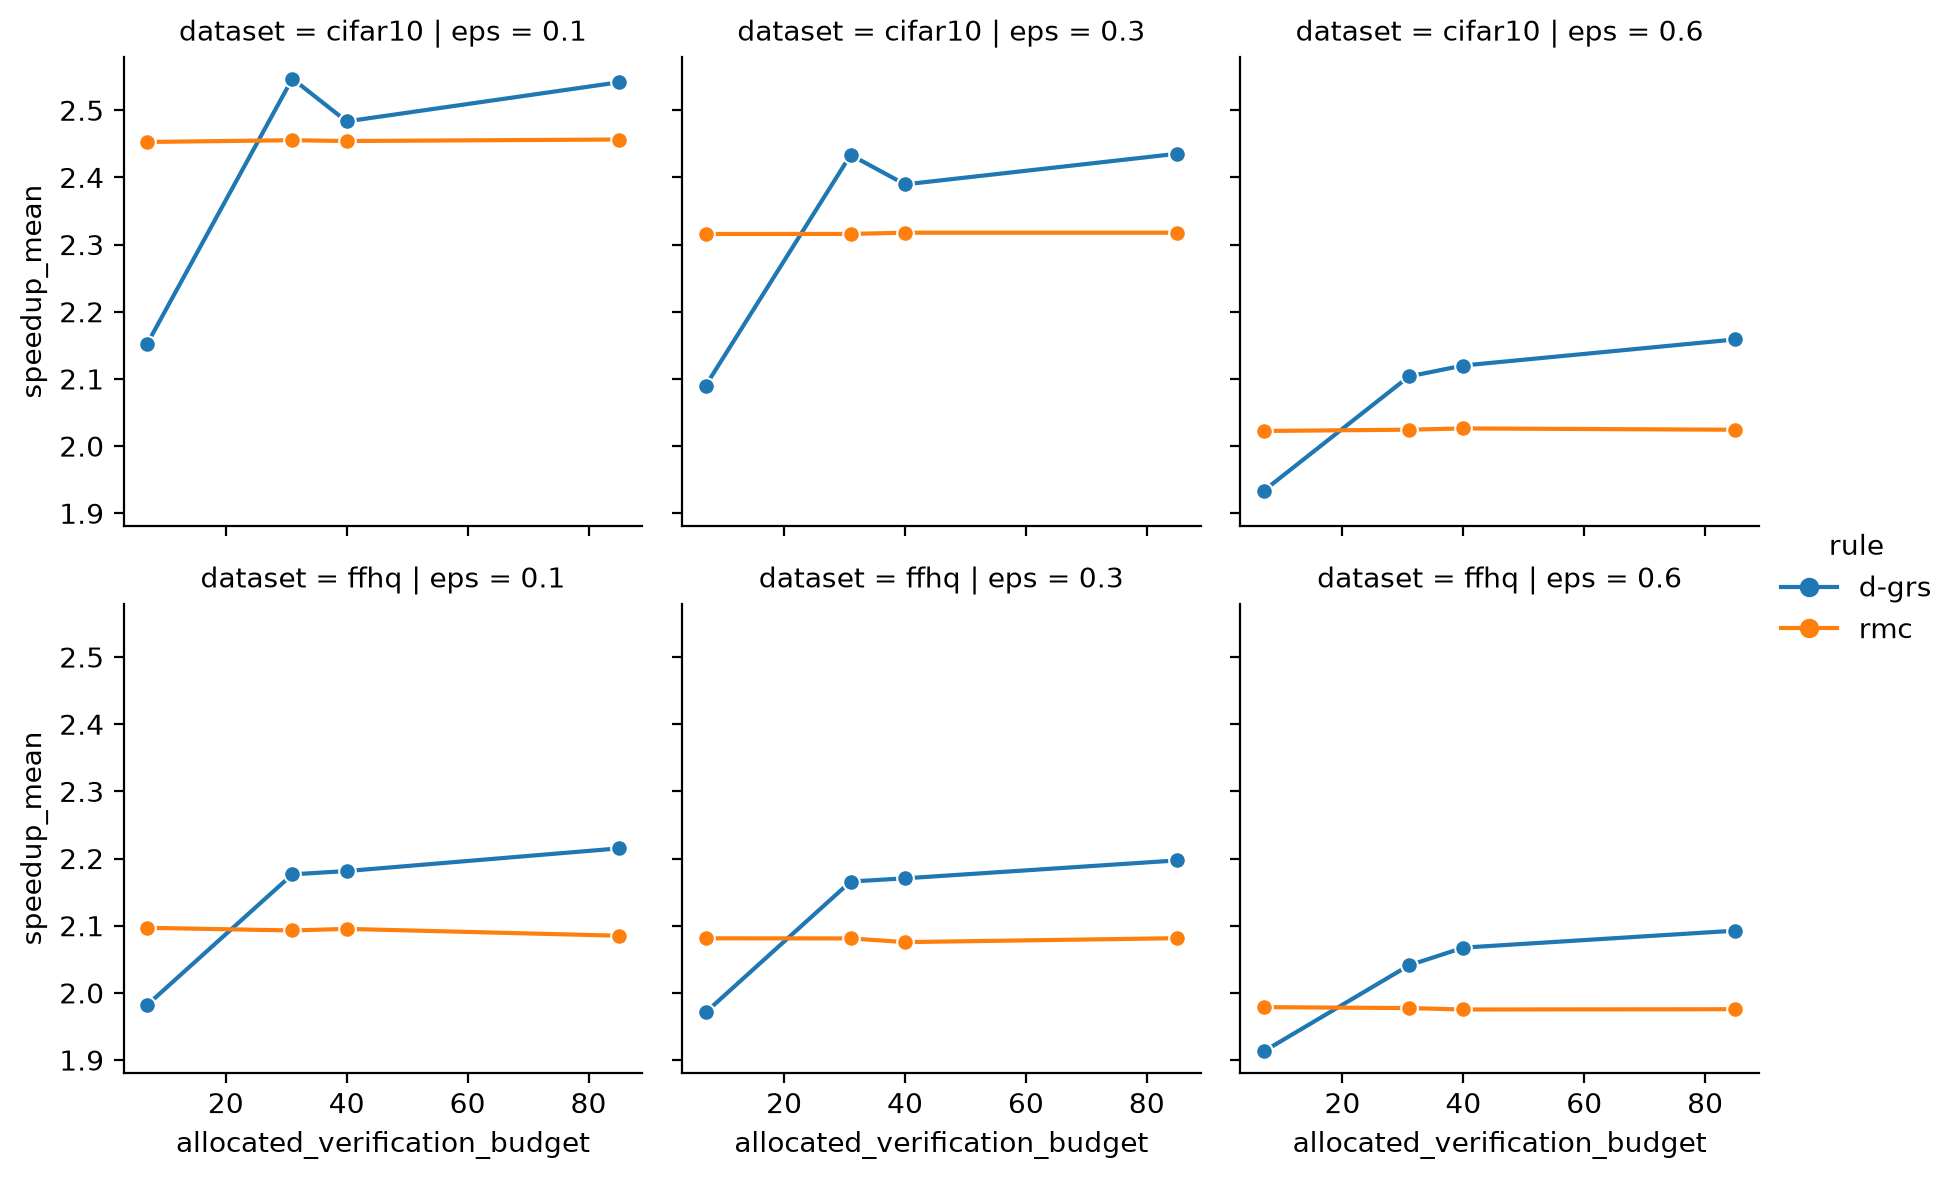

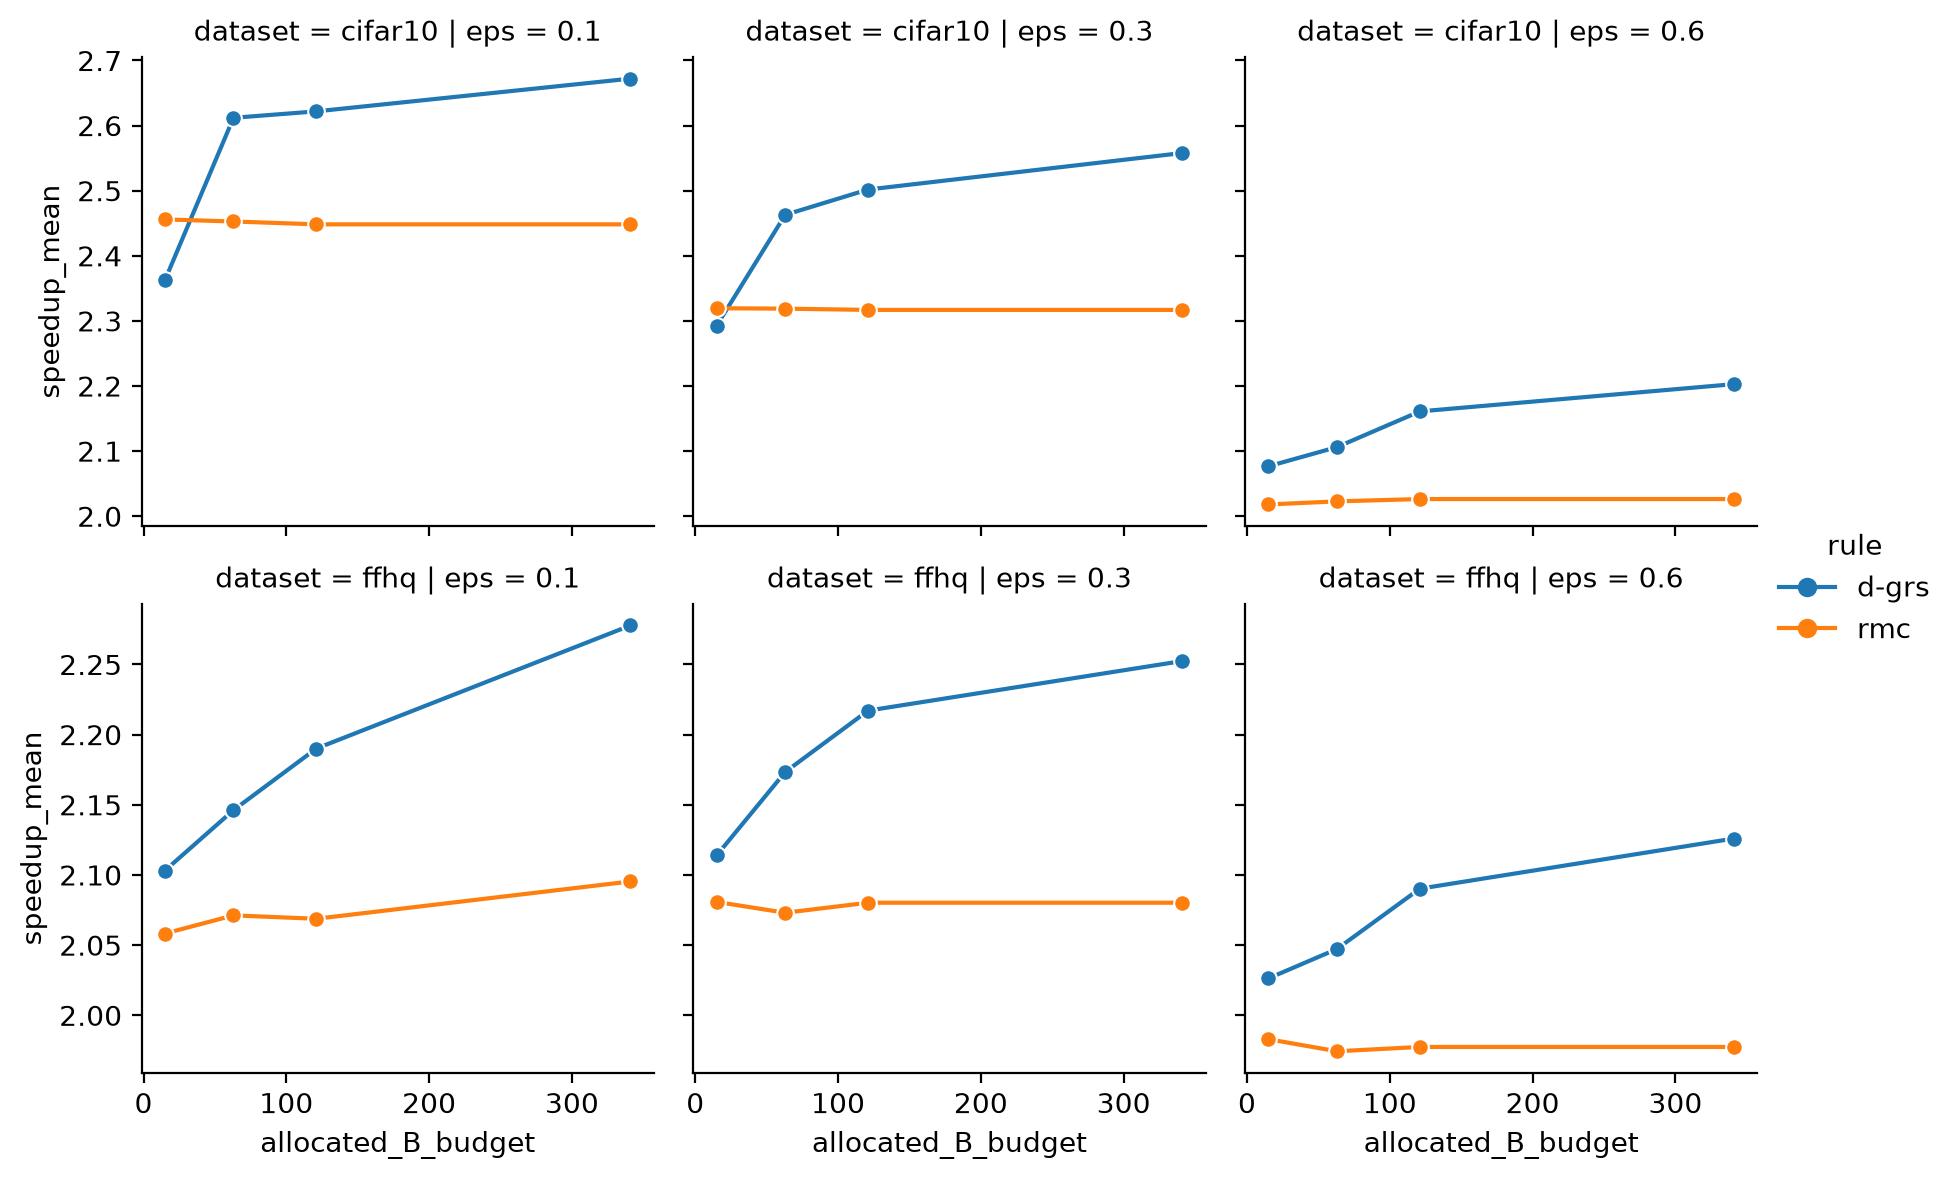

In [50]:
speedup_df = image_results[
    (image_results["family"] == "edm") & (image_results["rule"] != "target") & (image_results["match"] == "verification")
]

sns.relplot(
    data=speedup_df,
    x="allocated_verification_budget",
    y="speedup_mean",
    hue="rule",
    # style="match",
    marker="o",
    col="eps",
    row="dataset",
    kind="line",
    height=3,
    aspect=1,
    #facet_kws={"sharey": "row"},
)

speedup_df = image_results[
    (image_results["family"] == "edm") & (image_results["rule"] != "target") & (image_results["match"] == "budget")
]

sns.relplot(
    data=speedup_df,
    x="allocated_B_budget",
    y="speedup_mean",
    hue="rule",
    # style="match",
    marker="o",
    col="eps",
    row="dataset",
    kind="line",
    height=3,
    aspect=1,
    facet_kws={"sharey": "row"}
)

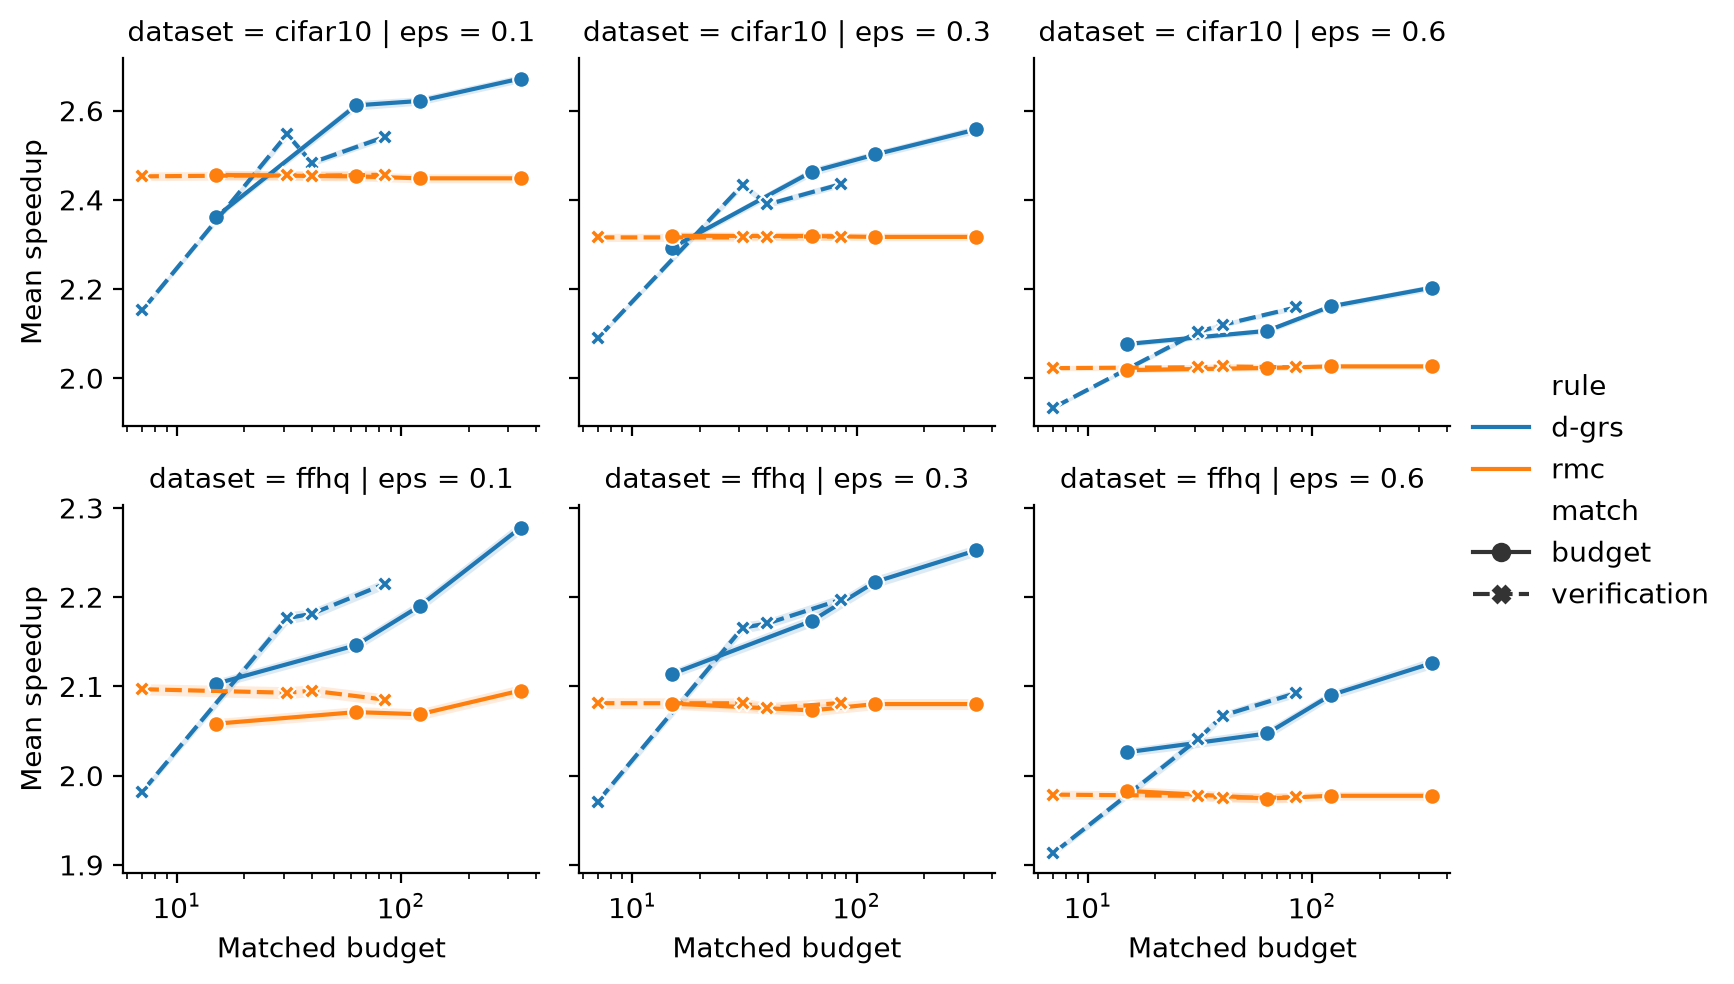

In [51]:
speedup_df = image_results.loc[
    image_results["family"].eq("edm")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(rules, sns.color_palette(n_colors=len(rules))))

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="match",
    markers=True,
    dashes=True,
    col="eps",
    row="dataset",
    kind="line",
    estimator=None,  # Plot the supplied means directly.
    errorbar=None,
    height=2.5,
    aspect=1.,
    facet_kws={"sharey": "row"},
)

for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for (rule, match), curve in panel.groupby(["rule", "match"]):
        curve = curve.sort_values("matched_budget")
        ax.fill_between(
            curve["matched_budget"].to_numpy(),
            curve["ci_low"].to_numpy(),
            curve["ci_high"].to_numpy(),
            color=palette[rule],
            alpha=0.15,
            linewidth=0,
        )

g.set_axis_labels("Matched budget", "Mean speedup")
g.set(xscale="log")

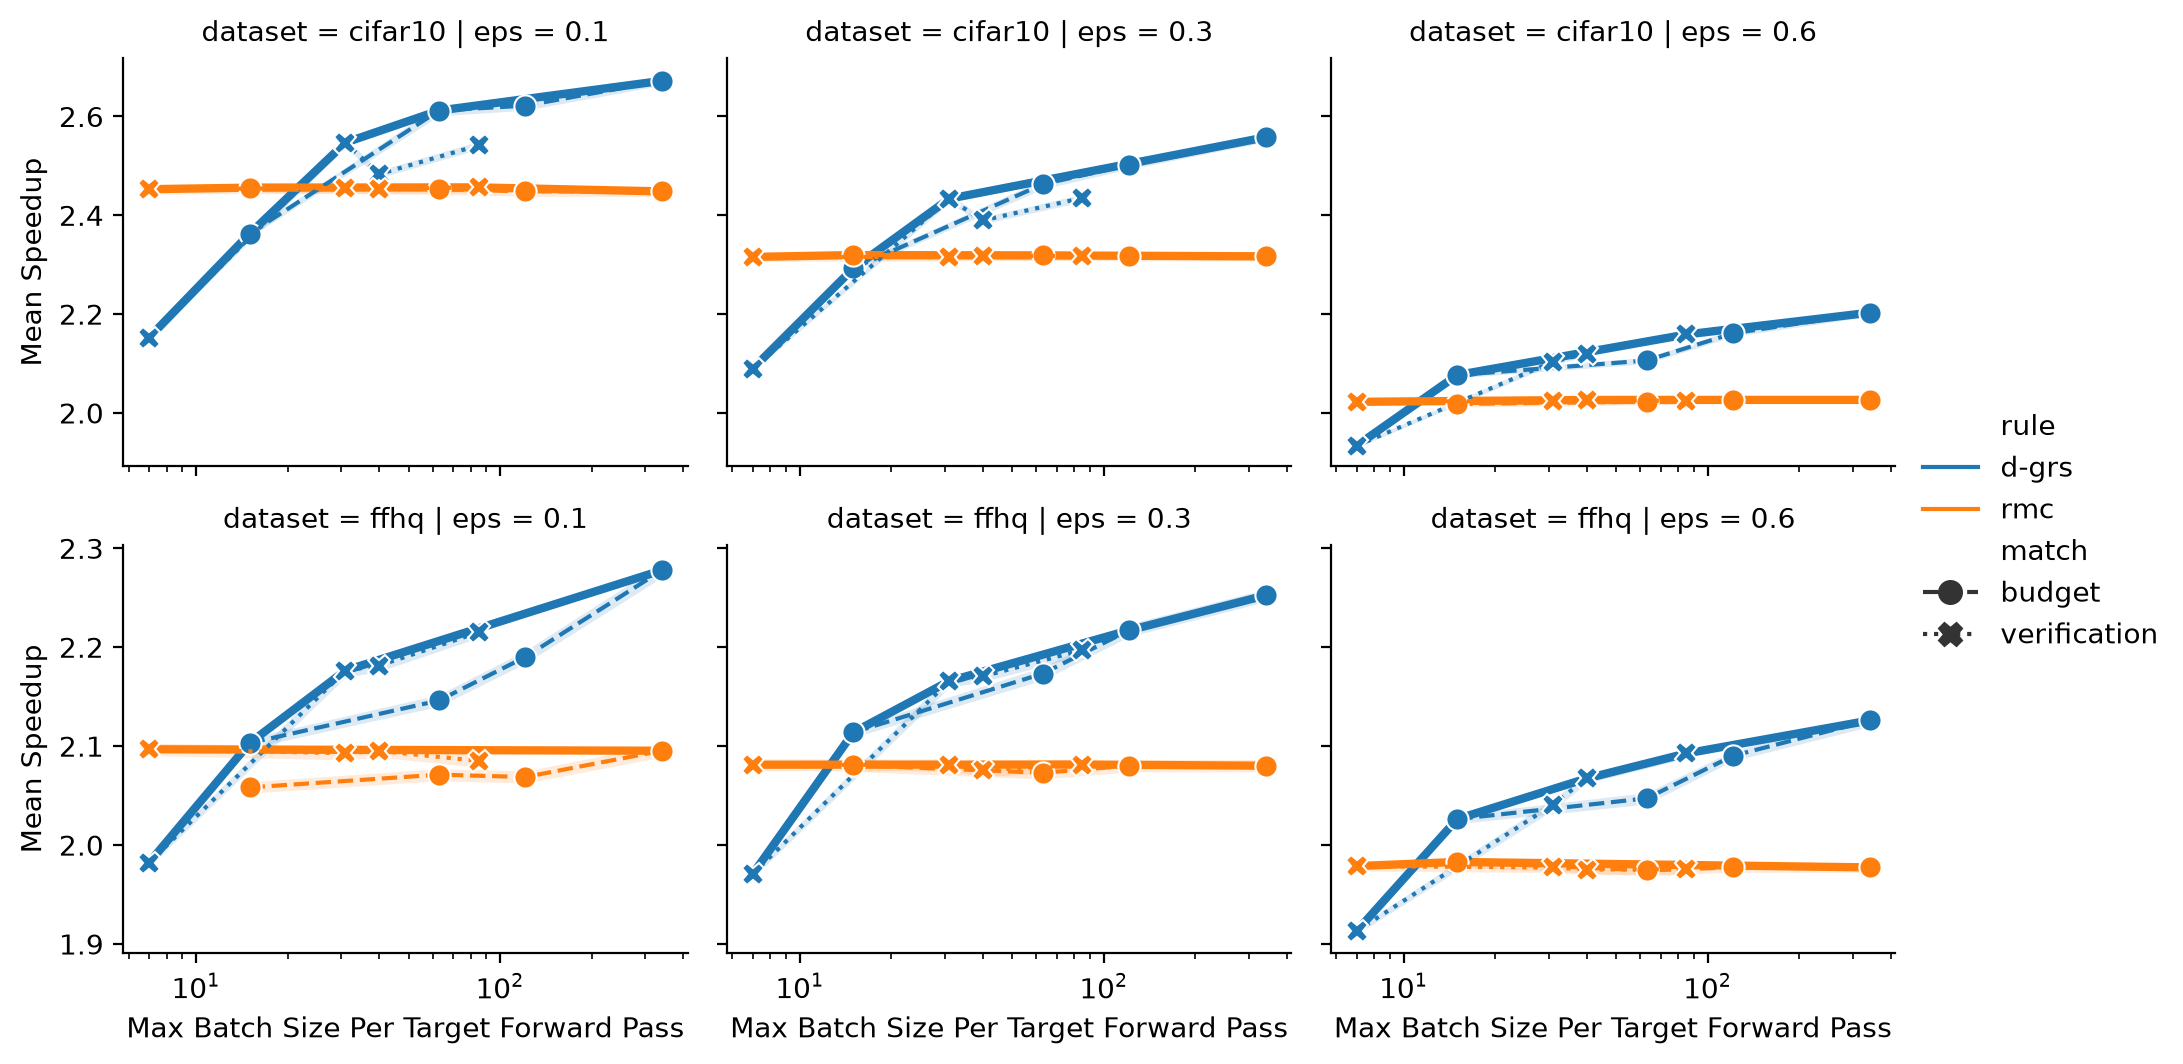

In [52]:
speedup_df = image_results.loc[
    image_results["family"].eq("edm")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(rules, sns.color_palette(n_colors=len(rules))))

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="match",
    markers=True,
    #dashes=True,
    col="eps",
    row="dataset",
    kind="line",
    estimator=None,  # Plot the supplied means directly.
    errorbar=None,
    height=2.7,
    aspect=1.2,
    facet_kws={"sharey": "row"},
    alpha=1,
    markersize=8,
    dashes={
        "verification": (1, 1.65),  # ":"  dotted
        "budget": (3.7, 1.6),       # "--" dashed
    },
)

for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for (rule, match), curve in panel.groupby(["rule", "match"]):
        curve = curve.sort_values("matched_budget")
        ax.fill_between(
            curve["matched_budget"].to_numpy(),
            curve["ci_low"].to_numpy(),
            curve["ci_high"].to_numpy(),
            color=palette[rule],
            alpha=0.15,
            linewidth=0,
        )

g.set_axis_labels("Max Batch Size Per Target Forward Pass", "Mean Speedup")
g.set(xscale="log")


def upper_concave_envelope(curve, log_x=True):
    points = (
        curve[["matched_budget", "speedup_mean"]]
        .dropna()
        .groupby("matched_budget", as_index=False)["speedup_mean"]
        .max()
        .sort_values("matched_budget")
    )

    if log_x:
        points = points.loc[points["matched_budget"] > 0]

    budget = points["matched_budget"].to_numpy(dtype=float)
    y = points["speedup_mean"].to_numpy(dtype=float)
    x = np.log10(budget) if log_x else budget

    hull = []
    for i in range(len(x)):
        while len(hull) >= 2:
            a, b = hull[-2:]

            # Concavity requires slope(a,b) >= slope(b,i).
            left = (y[b] - y[a]) * (x[i] - x[b])
            right = (y[i] - y[b]) * (x[b] - x[a])

            if left > right:
                break

            hull.pop()

        hull.append(i)

    return budget[hull], y[hull]


for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for rule, curve in panel.groupby("rule"):
        x, y = upper_concave_envelope(curve, log_x=True)

        ax.plot(
            x, y,
            color=palette[rule],
            linewidth=3.,
            zorder=1,
            #marker='s'
        )

### Mean Acceprance Rate

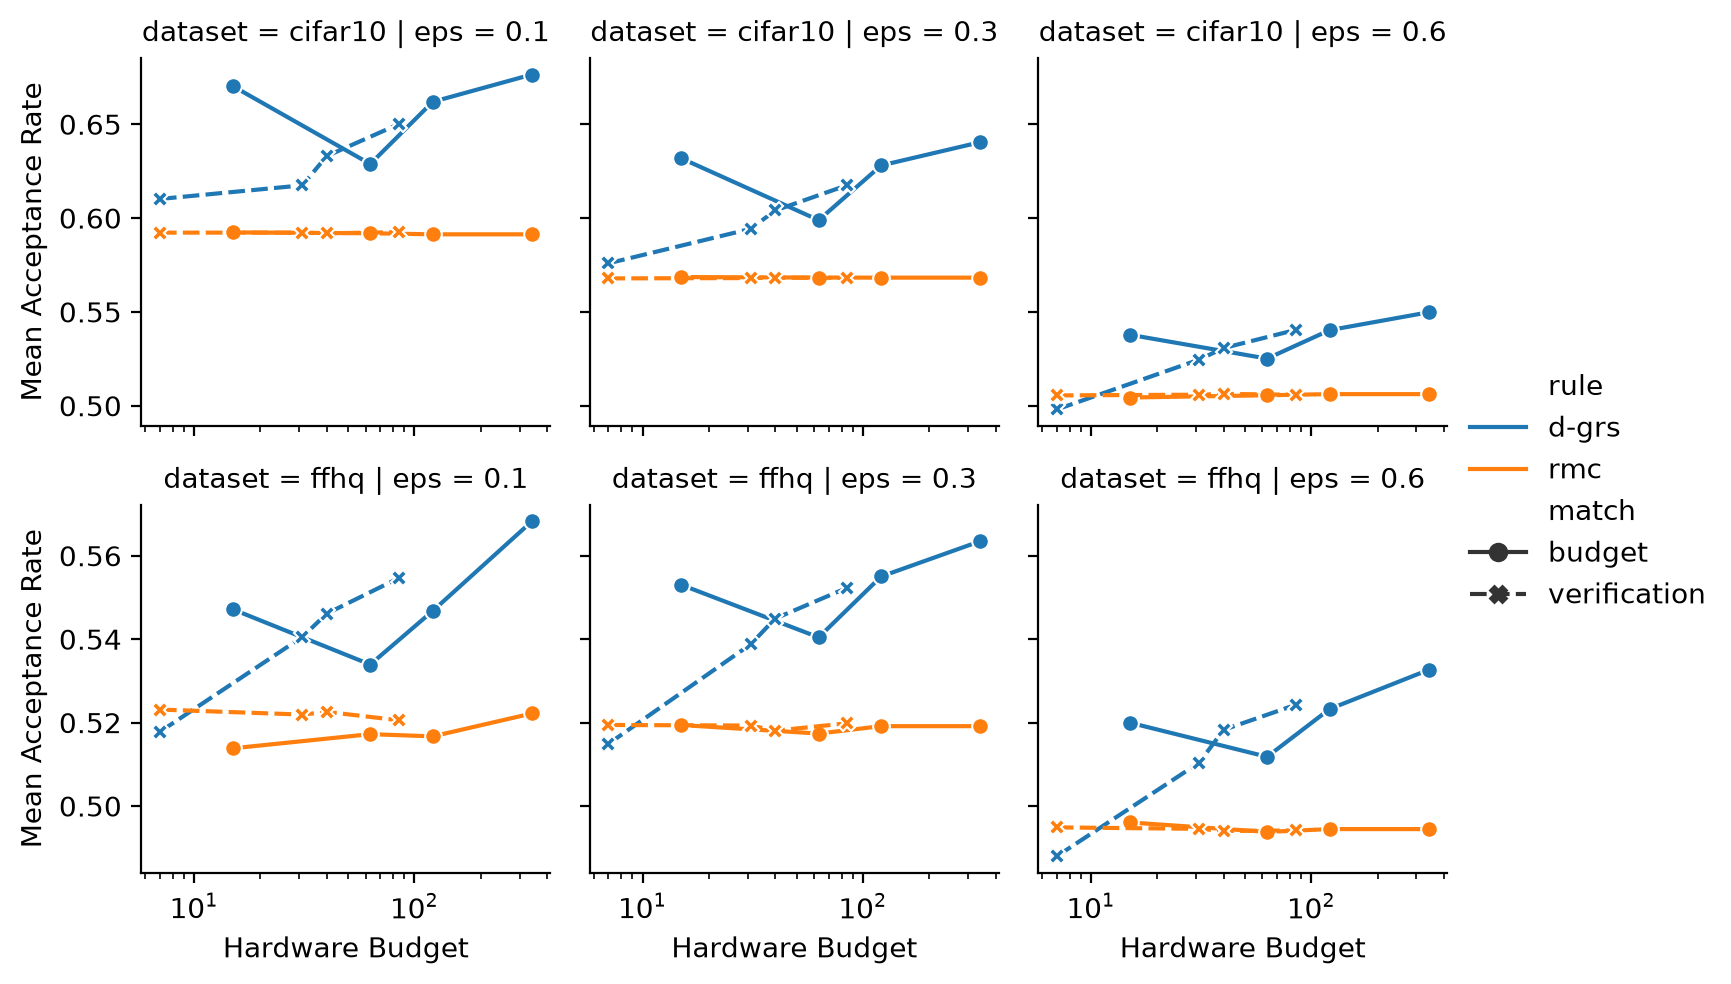

In [53]:
speedup_df = image_results.loc[
    image_results["family"].eq("edm") &
    image_results["rule"].ne("target") &
    image_results["match"].isin(["verification", "budget"])
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="acceptance_rate",
    hue="rule",
    style="match",
    markers=True,
    dashes=True,
    col="eps",
    row="dataset",
    kind="line",
    errorbar=None,
    height=2.5,
    aspect=1.,
    facet_kws={"sharey": "row"},
)

g.set_axis_labels("Hardware Budget", "Mean Acceptance Rate")
g.set(xscale="log")

## SD3

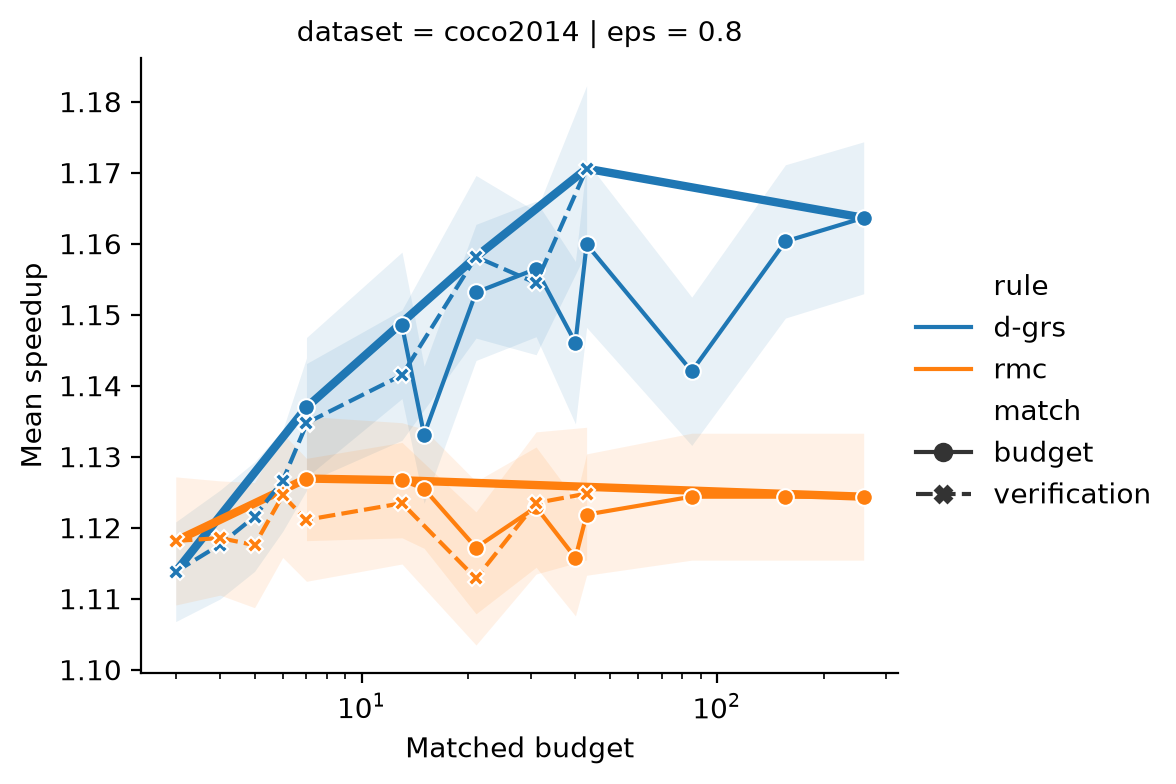

In [95]:
speedup_df = image_results.loc[
    image_results["family"].eq("sd3")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
    & image_results["L"].lt(4)
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

# Approximate 95% CI for the mean across independent trajectories.
margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(
    rules, sns.color_palette("tab10", n_colors=len(rules))
))

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="match",
    markers=True,
    dashes=True,
    col="eps",
    row="dataset",
    kind="line",
    estimator=None,
    errorbar=None,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": "row"},
)

for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for (rule, match), curve in panel.groupby(["rule", "match"]):
        curve = curve.sort_values("matched_budget")
        ax.fill_between(
            curve["matched_budget"].to_numpy(),
            curve["ci_low"].to_numpy(),
            curve["ci_high"].to_numpy(),
            color=palette[rule],
            alpha=0.1,
            linewidth=0,
        )

g.set_axis_labels("Matched budget", "Mean speedup")
g.set(xscale="log")

def upper_concave_envelope(curve, log_x=True):
    points = (
        curve[["matched_budget", "speedup_mean"]]
        .dropna()
        .groupby("matched_budget", as_index=False)["speedup_mean"]
        .max()
        .sort_values("matched_budget")
    )

    if log_x:
        points = points.loc[points["matched_budget"] > 0]

    budget = points["matched_budget"].to_numpy(dtype=float)
    y = points["speedup_mean"].to_numpy(dtype=float)
    x = np.log10(budget) if log_x else budget

    hull = []
    for i in range(len(x)):
        while len(hull) >= 2:
            a, b = hull[-2:]

            # Concavity requires slope(a,b) >= slope(b,i).
            left = (y[b] - y[a]) * (x[i] - x[b])
            right = (y[i] - y[b]) * (x[b] - x[a])

            if left > right:
                break

            hull.pop()

        hull.append(i)

    return budget[hull], y[hull]


for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for rule, curve in panel.groupby("rule"):
        x, y = upper_concave_envelope(curve, log_x=True)

        ax.plot(
            x, y,
            color=palette[rule],
            linewidth=3.,
            zorder=1,
            #marker='s'
        )

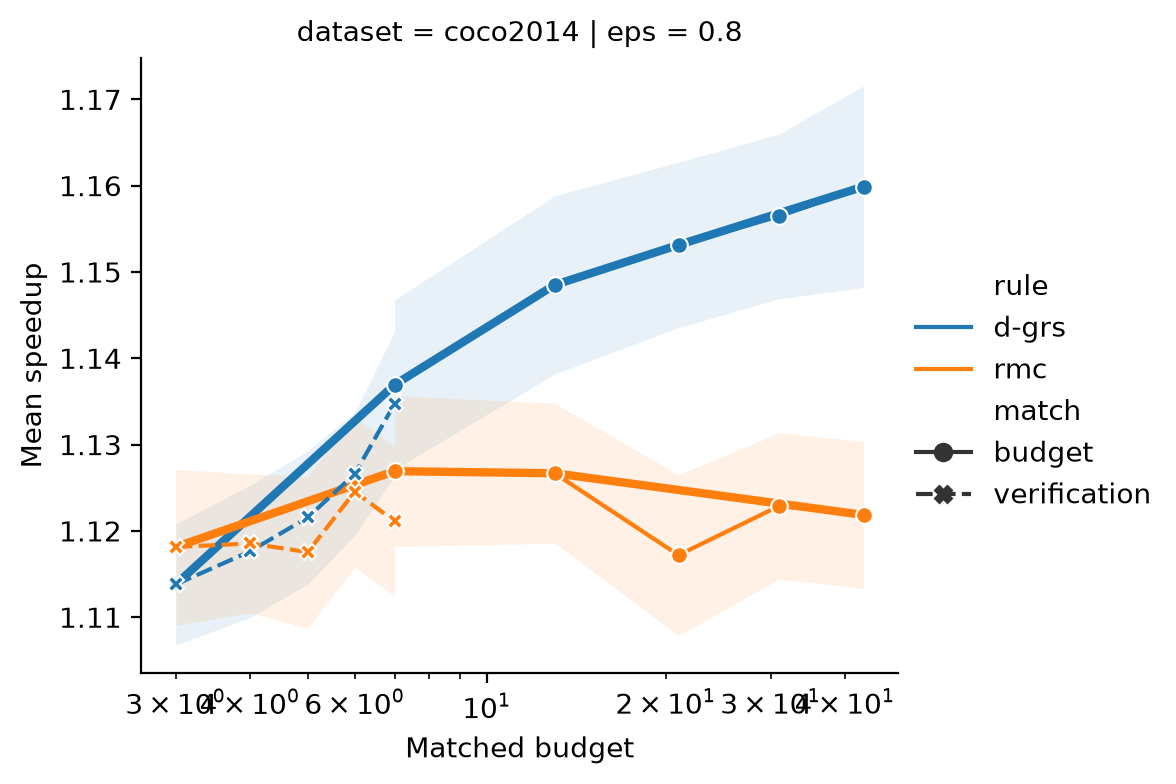

In [99]:
speedup_df = image_results.loc[
    image_results["family"].eq("sd3")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
    & image_results["L"].lt(3)
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

# Approximate 95% CI for the mean across independent trajectories.
margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(
    rules, sns.color_palette("tab10", n_colors=len(rules))
))

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="match",
    markers=True,
    dashes=True,
    col="eps",
    row="dataset",
    kind="line",
    estimator=None,
    errorbar=None,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": "row"},
)

for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for (rule, match), curve in panel.groupby(["rule", "match"]):
        curve = curve.sort_values("matched_budget")
        ax.fill_between(
            curve["matched_budget"].to_numpy(),
            curve["ci_low"].to_numpy(),
            curve["ci_high"].to_numpy(),
            color=palette[rule],
            alpha=0.1,
            linewidth=0,
        )

g.set_axis_labels("Matched budget", "Mean speedup")
g.set(xscale="log")

def upper_concave_envelope(curve, log_x=True):
    points = (
        curve[["matched_budget", "speedup_mean"]]
        .dropna()
        .groupby("matched_budget", as_index=False)["speedup_mean"]
        .max()
        .sort_values("matched_budget")
    )

    if log_x:
        points = points.loc[points["matched_budget"] > 0]

    budget = points["matched_budget"].to_numpy(dtype=float)
    y = points["speedup_mean"].to_numpy(dtype=float)
    x = np.log10(budget) if log_x else budget

    hull = []
    for i in range(len(x)):
        while len(hull) >= 2:
            a, b = hull[-2:]

            # Concavity requires slope(a,b) >= slope(b,i).
            left = (y[b] - y[a]) * (x[i] - x[b])
            right = (y[i] - y[b]) * (x[b] - x[a])

            if left > right:
                break

            hull.pop()

        hull.append(i)

    return budget[hull], y[hull]


for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for rule, curve in panel.groupby("rule"):
        x, y = upper_concave_envelope(curve, log_x=True)

        ax.plot(
            x, y,
            color=palette[rule],
            linewidth=3.,
            zorder=1,
            #marker='s'
        )

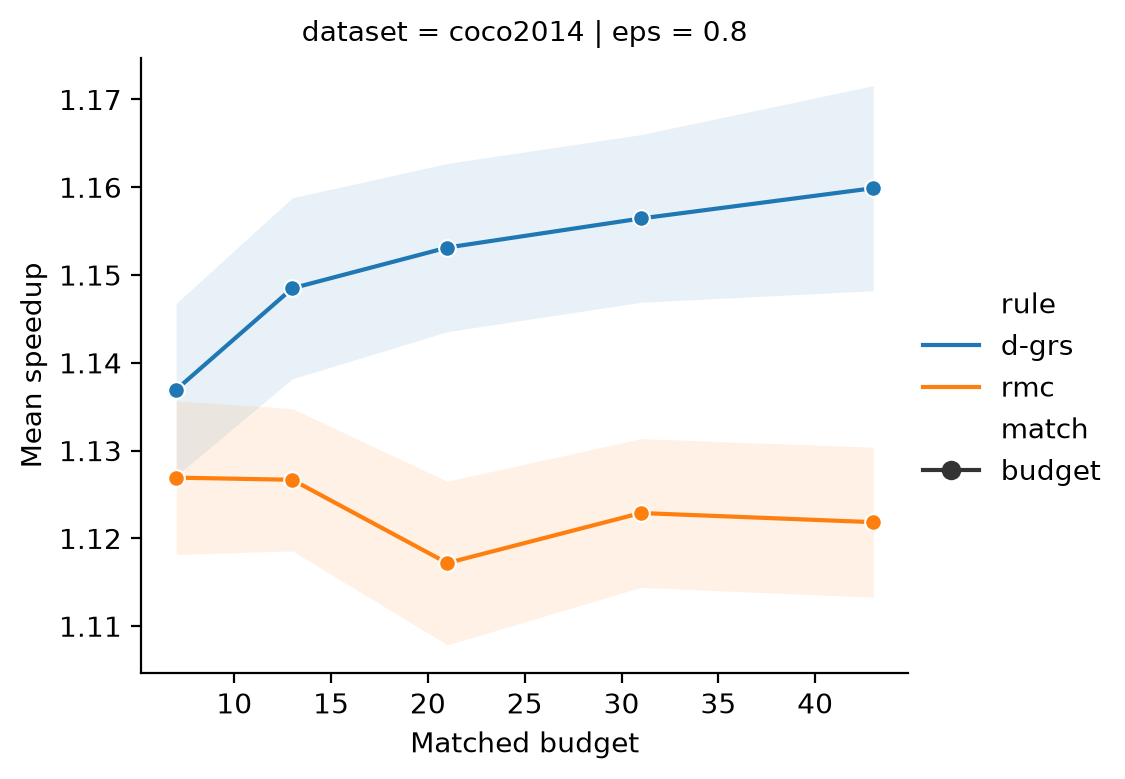

In [104]:
speedup_df = image_results.loc[
    image_results["family"].eq("sd3")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
    & image_results["L"].lt(3)
    & image_results["match"].eq("budget")
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

# Approximate 95% CI for the mean across independent trajectories.
margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(
    rules, sns.color_palette("tab10", n_colors=len(rules))
))

g = sns.relplot(
    data=speedup_df[speedup_df["match"]=="budget"],
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="match",
    markers=True,
    dashes=True,
    col="eps",
    row="dataset",
    kind="line",
    estimator=None,
    errorbar=None,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": "row"},
)

for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for (rule, match), curve in panel.groupby(["rule", "match"]):
        curve = curve.sort_values("matched_budget")
        ax.fill_between(
            curve["matched_budget"].to_numpy(),
            curve["ci_low"].to_numpy(),
            curve["ci_high"].to_numpy(),
            color=palette[rule],
            alpha=0.1,
            linewidth=0,
        )

g.set_axis_labels("Matched budget", "Mean speedup")
#g.set(xscale="log")

# def upper_concave_envelope(curve, log_x=True):
#     points = (
#         curve[["matched_budget", "speedup_mean"]]
#         .dropna()
#         .groupby("matched_budget", as_index=False)["speedup_mean"]
#         .max()
#         .sort_values("matched_budget")
#     )

#     if log_x:
#         points = points.loc[points["matched_budget"] > 0]

#     budget = points["matched_budget"].to_numpy(dtype=float)
#     y = points["speedup_mean"].to_numpy(dtype=float)
#     x = np.log10(budget) if log_x else budget

#     hull = []
#     for i in range(len(x)):
#         while len(hull) >= 2:
#             a, b = hull[-2:]

#             # Concavity requires slope(a,b) >= slope(b,i).
#             left = (y[b] - y[a]) * (x[i] - x[b])
#             right = (y[i] - y[b]) * (x[b] - x[a])

#             if left > right:
#                 break

#             hull.pop()

#         hull.append(i)

#     return budget[hull], y[hull]


# for (dataset, eps), ax in g.axes_dict.items():
#     panel = speedup_df.loc[
#         speedup_df["dataset"].eq(dataset)
#         & speedup_df["eps"].eq(eps)
#     ]

#     for rule, curve in panel.groupby("rule"):
#         x, y = upper_concave_envelope(curve, log_x=True)

#         ax.plot(
#             x, y,
#             color=palette[rule],
#             linewidth=3.,
#             zorder=1,
#             #marker='s'
#         )

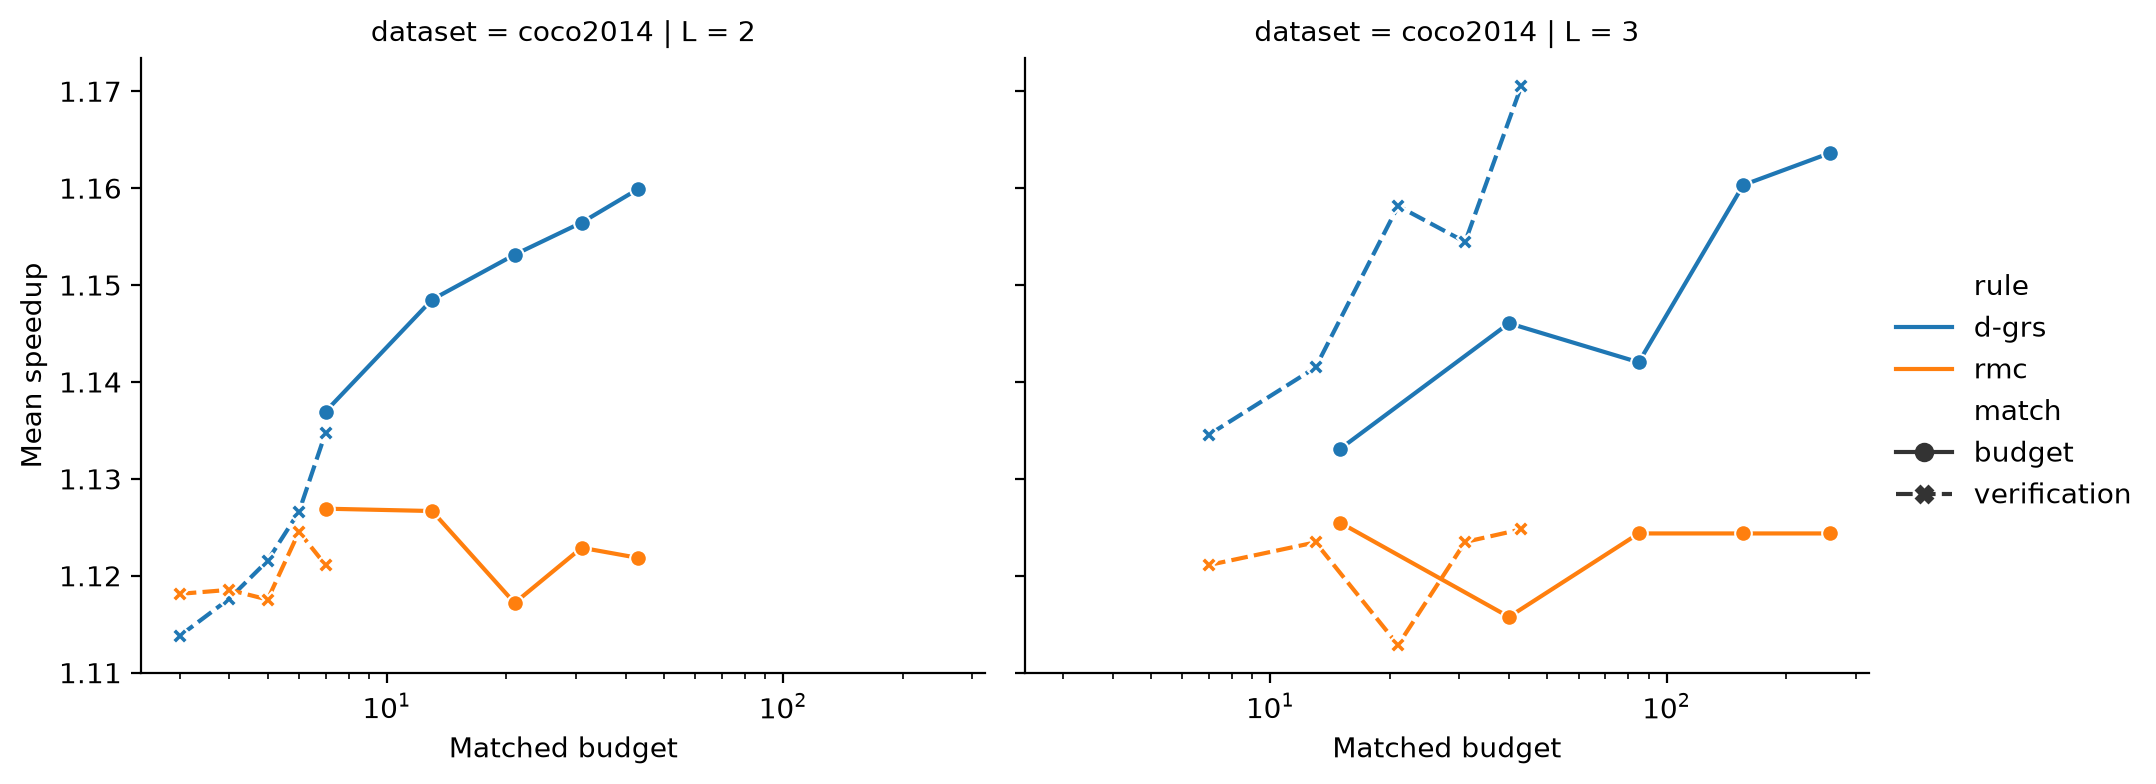

In [93]:
speedup_df = image_results.loc[
    image_results["family"].eq("sd3")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
    & image_results["L"].lt(4)
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

# Approximate 95% CI for the mean across independent trajectories.
margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(
    rules, sns.color_palette("tab10", n_colors=len(rules))
))

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="match",
    markers=True,
    dashes=True,
    col="L",
    row="dataset",
    kind="line",
    estimator=None,
    errorbar=None,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": "row"},
)

for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for (rule, match), curve in panel.groupby(["rule", "match"]):
        curve = curve.sort_values("matched_budget")
        ax.fill_between(
            curve["matched_budget"].to_numpy(),
            curve["ci_low"].to_numpy(),
            curve["ci_high"].to_numpy(),
            color=palette[rule],
            alpha=0.1,
            linewidth=0,
        )

g.set_axis_labels("Matched budget", "Mean speedup")
g.set(xscale="log")

def upper_concave_envelope(curve, log_x=True):
    points = (
        curve[["matched_budget", "speedup_mean"]]
        .dropna()
        .groupby("matched_budget", as_index=False)["speedup_mean"]
        .max()
        .sort_values("matched_budget")
    )

    if log_x:
        points = points.loc[points["matched_budget"] > 0]

    budget = points["matched_budget"].to_numpy(dtype=float)
    y = points["speedup_mean"].to_numpy(dtype=float)
    x = np.log10(budget) if log_x else budget

    hull = []
    for i in range(len(x)):
        while len(hull) >= 2:
            a, b = hull[-2:]

            # Concavity requires slope(a,b) >= slope(b,i).
            left = (y[b] - y[a]) * (x[i] - x[b])
            right = (y[i] - y[b]) * (x[b] - x[a])

            if left > right:
                break

            hull.pop()

        hull.append(i)

    return budget[hull], y[hull]


for (dataset, eps), ax in g.axes_dict.items():
    panel = speedup_df.loc[
        speedup_df["dataset"].eq(dataset)
        & speedup_df["eps"].eq(eps)
    ]

    for rule, curve in panel.groupby("rule"):
        x, y = upper_concave_envelope(curve, log_x=True)

        ax.plot(
            x, y,
            color=palette[rule],
            linewidth=3.,
            zorder=1,
            #marker='s'
        )

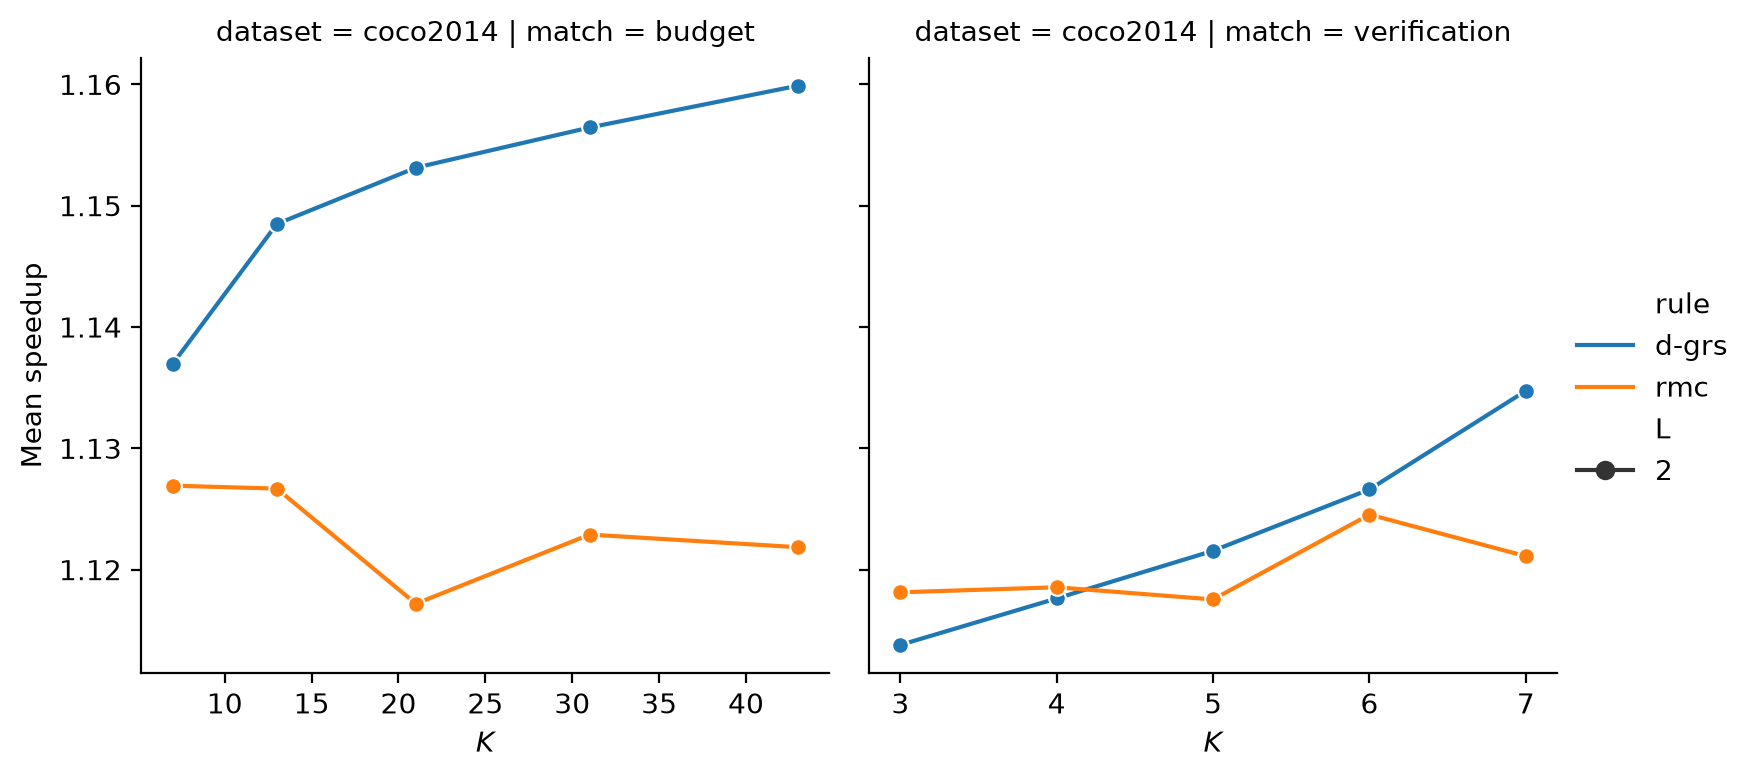

In [83]:
speedup_df = image_results.loc[
    image_results["family"].eq("sd3")
    & image_results["rule"].ne("target")
    & image_results["match"].isin(["verification", "budget"])
    & image_results["L"].lt(3)
].copy()

speedup_df["matched_budget"] = np.where(
    speedup_df["match"].eq("verification"),
    speedup_df["verification_budget"],
    speedup_df["allocated_B_budget"],
)

# Approximate 95% CI for the mean across independent trajectories.
margin = 1.96 * speedup_df["speedup_std"] / np.sqrt(
    speedup_df["num_samples"]
)
speedup_df["ci_low"] = speedup_df["speedup_mean"] - margin
speedup_df["ci_high"] = speedup_df["speedup_mean"] + margin

rules = sorted(speedup_df["rule"].unique())
palette = dict(zip(
    rules, sns.color_palette("tab10", n_colors=len(rules))
))

g = sns.relplot(
    data=speedup_df,
    x="matched_budget",
    y="speedup_mean",
    hue="rule",
    palette=palette,
    style="L",
    markers=True,
    dashes=True,
    col="match",
    row="dataset",
    kind="line",
    estimator=None,
    errorbar=None,
    height=4,
    aspect=1.,
    facet_kws={"sharey": "row", "sharex": "col"},
)

# for (dataset, match), ax in g.axes_dict.items():
#     panel = speedup_df.loc[
#         speedup_df["dataset"].eq(dataset)
#         & speedup_df["match"].eq(match)
#     ]

#     for (rule, depth), curve in panel.groupby(["rule", "L"]):
#         curve = curve.sort_values("K")
#         ax.fill_between(
#             curve["K"].to_numpy(),
#             curve["ci_low"].to_numpy(),
#             curve["ci_high"].to_numpy(),
#             color=palette[rule],
#             alpha=0.1,
#             linewidth=0,
#         )

g.set_axis_labels(r"$K$", "Mean speedup")
#g.set(xscale="log")

## Gaussian-mixture experiment (`gm`)

The Gaussian-mixture sweep has three complementary sources: replicate-level measurements in `raw.csv`, cell-level statistics in `summary.csv`, and run-wide parameters in `config.json`. The comprehensive `gm_results` table below keeps one row per `(source_run, rule, K, L, replicate)`, joins cell summaries many-to-one, broadcasts every configuration parameter with a `config_` prefix, and adds provenance plus derived efficiency metrics. The original `gm_raw` and `gm_summary` tables remain available for auditing.

In [22]:
def load_csv_group(filename: str) -> pd.DataFrame:
    frames = []
    for path in sorted((RESULTS_DIR / "gm").glob(f"*/{filename}")):
        frame = pd.read_csv(path)
        frame.insert(0, "source_run", path.parent.name)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


gm_raw = load_csv_group("raw.csv")
gm_raw.drop(columns=["chain_depth", "target_rows"], inplace=True)
gm_raw.rename(columns={"replicate": "sample_idx"}, inplace=True)

# Compute average speedup and standard deviation of speedup for each combination of K and L
gm_raw["speedup"] = gm_raw["num_steps"] / gm_raw["target_calls"]
gm_raw["acceptance_rate"] = gm_raw["accepted_depth"] / gm_raw["num_steps"]

# Compute the verification budget, that is the number of the internal nodes of the tree with depth L and width K
def compute_verification_budget(row):
    K = row['K']
    L = row['L']
    return (K ** L - 1) // (K - 1) if K > 1 else L
gm_raw["verification_budget"] = gm_raw.apply(compute_verification_budget, axis=1)


# gm_summary = load_csv_group("summary.csv")
# Create summary dataframe
gm_summary = (
    gm_raw.groupby(["K", "L", "rule"], as_index=False)
      .agg(
          speedup_mean=("speedup", "mean"),
          speedup_std=("speedup", "std"),
          acceptance_rate_mean=("acceptance_rate", "mean"),
          acceptance_rate_std=("acceptance_rate", "std"),
          NFE_mean=("target_calls", "mean"),
          NFE_std=("target_calls", "std"),
          round_mean=("rounds", "mean"),
          round_std=("rounds", "std"),
          accepted_depth_mean=("accepted_depth", "mean"),
          accepted_depth_std=("accepted_depth", "std"),
          num_samples=("sample_idx", "count"),
          verification_budget=("verification_budget", "first"),
          B=("B", "first")
      )
)

print(f"gm_raw:     {gm_raw.shape[0]:,} rows × {gm_raw.shape[1]:,} columns")
print(f"gm_summary: {gm_summary.shape[0]:,} rows × {gm_summary.shape[1]:,} columns")
display(gm_raw)
print("-" * 173)
display(gm_summary)

KeyError: "['chain_depth', 'target_rows'] not found in axis"

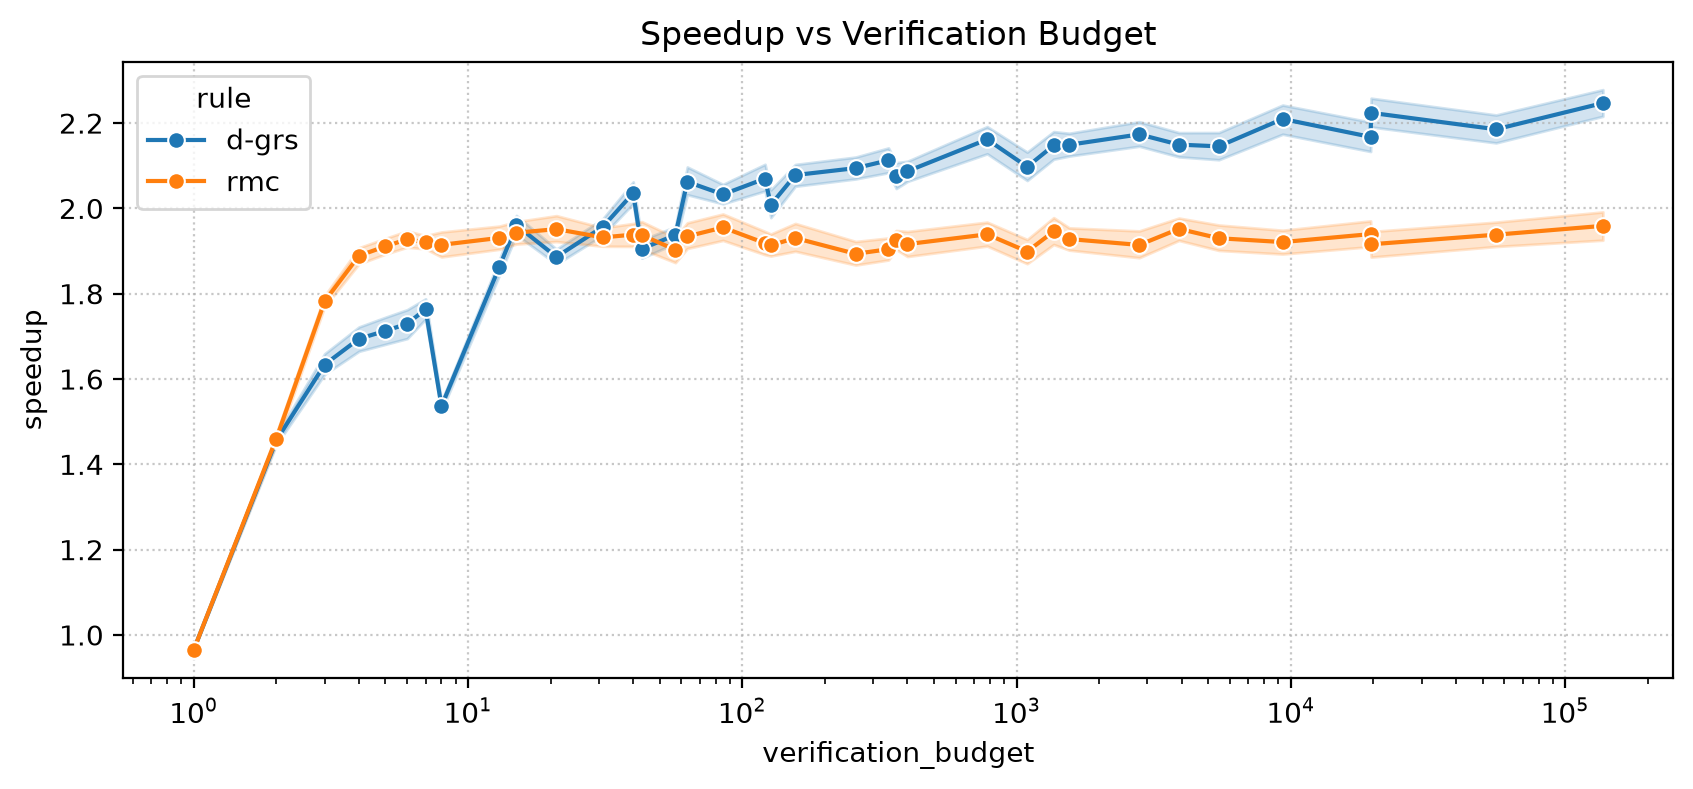

In [7]:
# Add logscale in x-axis for verification_budget and y-axis for speedup
plt.figure(figsize=(10, 4))

sns.lineplot(
    data=gm_raw, 
    x="verification_budget", 
    y="speedup", 
    hue="rule", 
    marker="o",
    estimator='mean',
    errorbar=('ci', 95),
)
plt.xscale("log")
plt.grid(linestyle=':', alpha=0.7)
plt.title("Speedup vs Verification Budget")
plt.show()

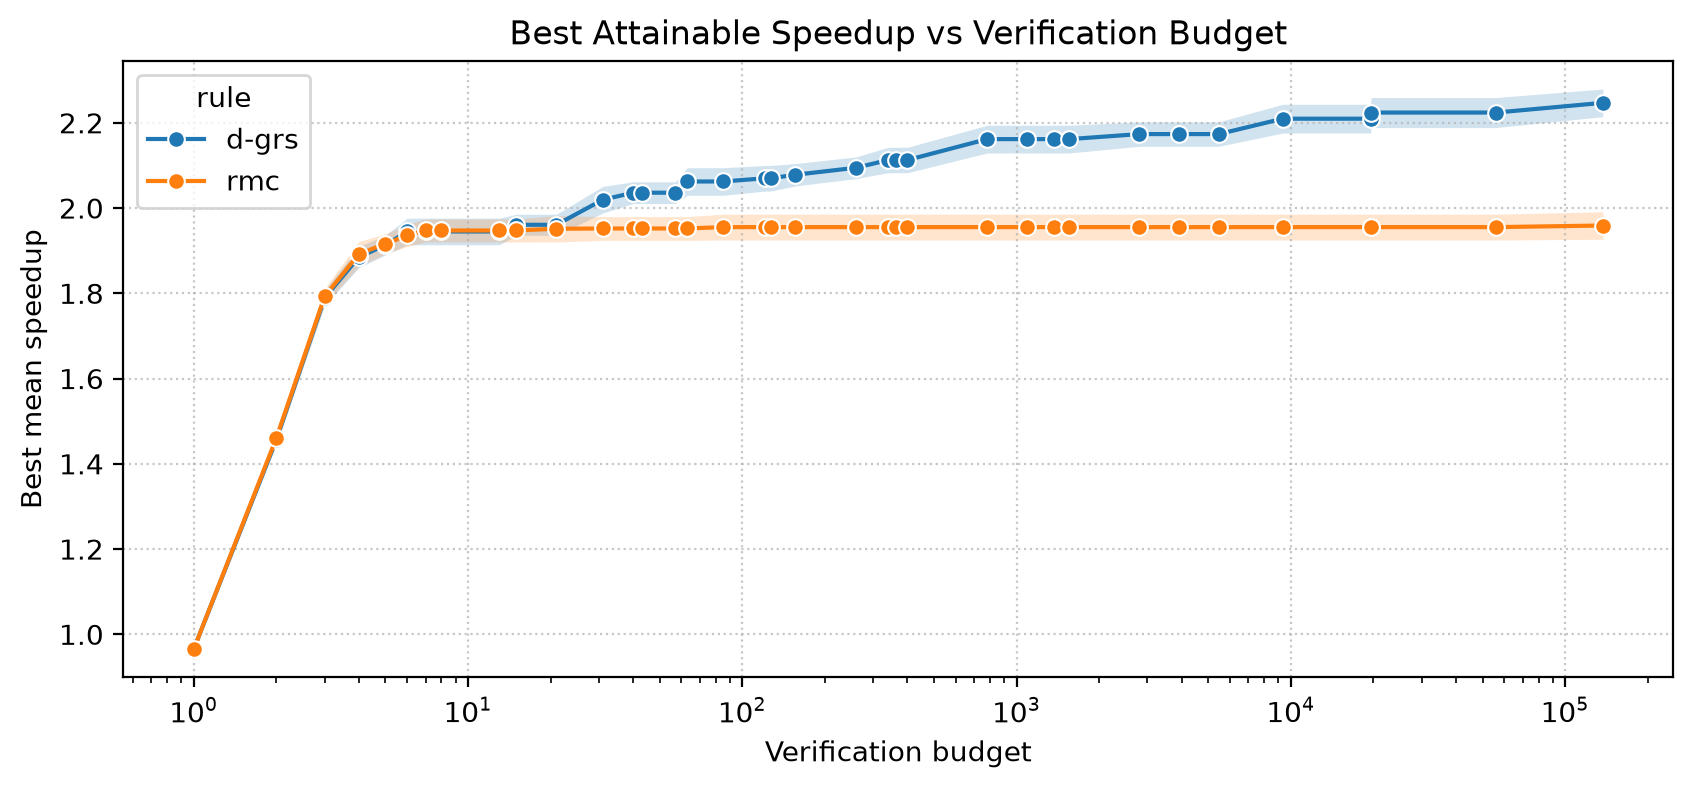

In [8]:
budget_limits = sorted(gm_raw["verification_budget"].unique())

# Select the best eligible configuration at every budget limit
best_rows = []

for rule, rule_stats in gm_summary.groupby("rule"):
    for limit in budget_limits:
        feasible = rule_stats[
            rule_stats["verification_budget"] <= limit
        ]

        if not feasible.empty:
            best = feasible.loc[[feasible["speedup_mean"].idxmax()]].copy()
            best["budget_limit"] = limit
            best_rows.append(best)

best_curve = pd.concat(best_rows, ignore_index=True)

rules = best_curve["rule"].dropna().unique()
colors = dict(
    zip(rules, sns.color_palette("tab10", n_colors=len(rules)))
)


fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data=best_curve,
    x="budget_limit",
    y="speedup_mean",
    hue="rule",
    marker="o",
    estimator=None,
    errorbar=None,
    ax=ax
)

# Add mean ± standard deviation
for rule, group in best_curve.groupby("rule"):
    group = group.sort_values("budget_limit")

    x = group["budget_limit"].to_numpy()
    mean = group["speedup_mean"].to_numpy()
    std = group["speedup_std"].to_numpy()
    ci = 1.96*std/group["num_samples"]**0.5

    ax.fill_between(
        x,
        mean - ci,
        mean + ci,
        color=colors[rule],
        alpha=0.2,
        linewidth=0,
    )

ax.set_xscale("log")
ax.grid(linestyle=":", alpha=0.7)
ax.set_xlabel("Verification budget")
ax.set_ylabel("Best mean speedup")
ax.set_title("Best Attainable Speedup vs Verification Budget")

plt.show()

### Accepted Depth
`accepted_depth` is the total number of consecutive speculative levels accepted across all rounds of one trajectory.

Examples:
- Reject at the first level: `committed = 1`, `accepted_depth = 0`.
- Accept two levels, reject the third: `committed = 3`, `accepted_depth = 2`.
- Accept the entire lookahead of depth 4: `committed = 4`, `accepted_depth = 4`.

For D-GRS, accepting one of the $K$ candidates counts as one accepted level, not $K$ accepted proposals.

Therefore:
- `accepted_depth / rounds` is the mean accepted prefix length per round. It can exceed 1, so it is not an acceptance probability.
- `accepted_depth / num_steps` is the fraction of committed speculative levels that came from accepted proposals; this is the conventional acceptance rate here.

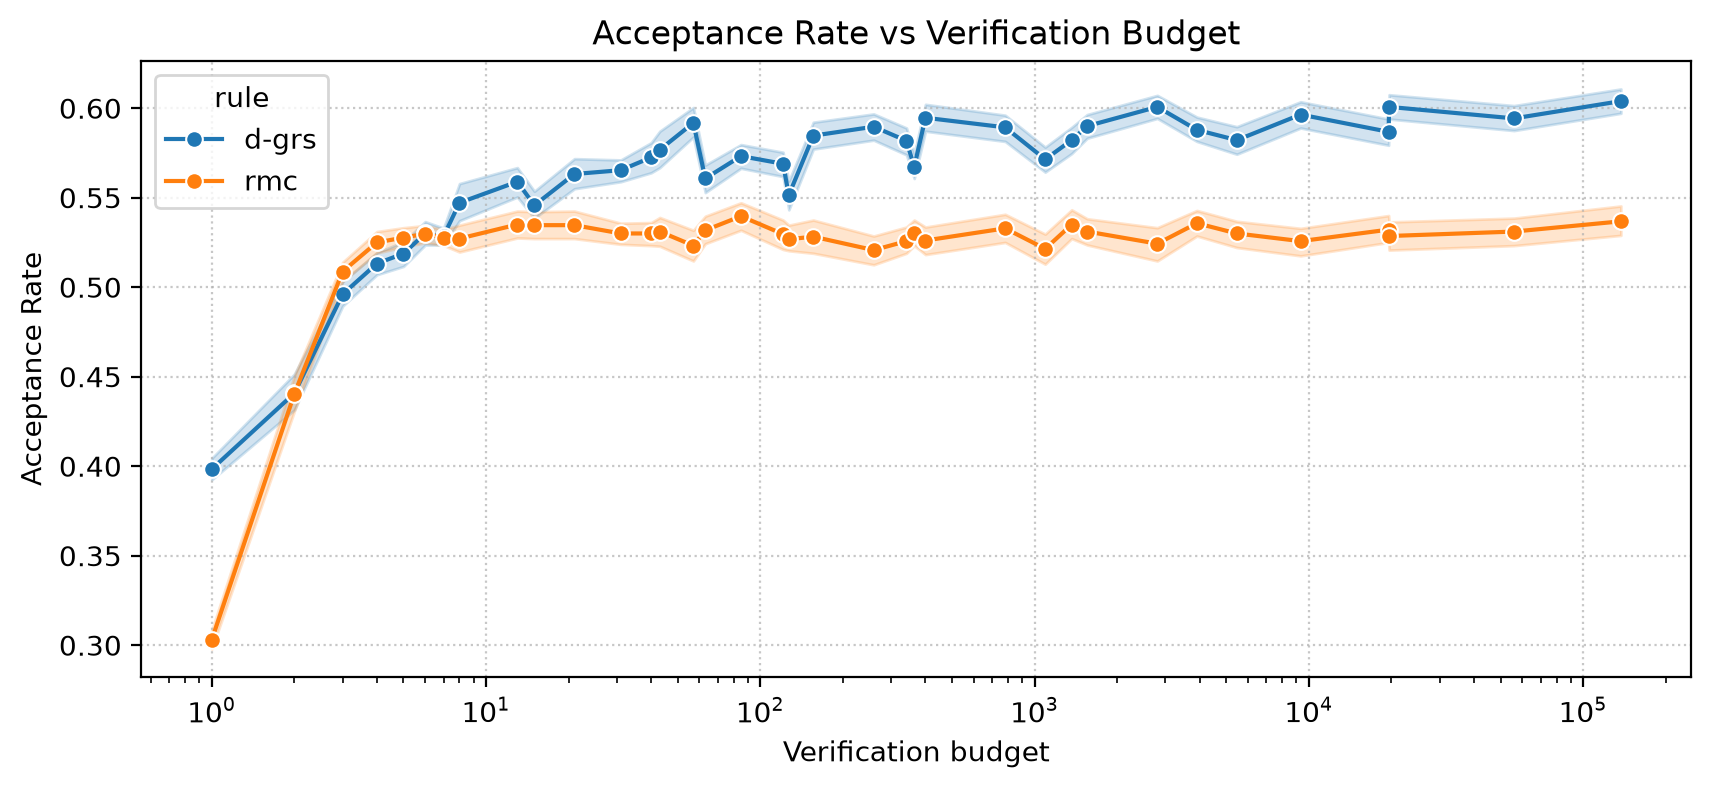

In [9]:
# Add logscale in x-axis for verification_budget and y-axis for speedup
plt.figure(figsize=(10, 4))

sns.lineplot(
    data=gm_raw, 
    x="verification_budget", 
    y="acceptance_rate", 
    hue="rule", 
    marker="o",
    estimator='mean',
    errorbar=('ci', 95),
)
plt.xscale("log")
plt.grid(linestyle=':', alpha=0.7)
plt.xlabel("Verification budget")
plt.ylabel("Acceptance Rate")
plt.title("Acceptance Rate vs Verification Budget")
plt.show()

### Speedup vs $K$ for different $L$ 

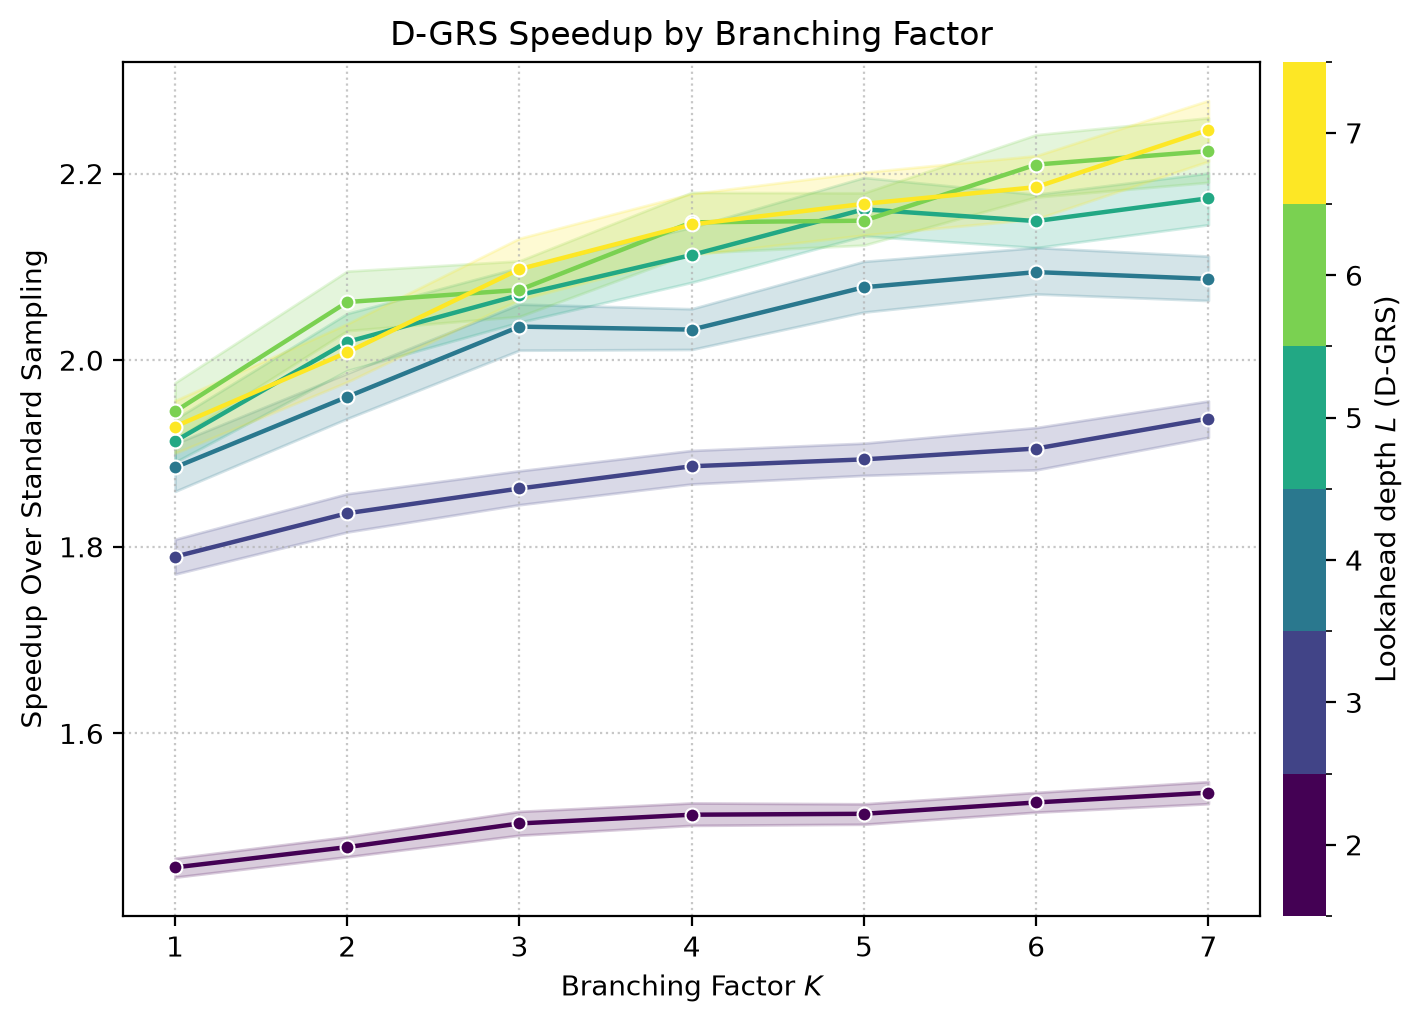

In [10]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only D-GRS configurations with meaningful lookahead
plot_df = gm_raw[
    (gm_raw["rule"] == "d-grs")
    & (gm_raw["L"] != 1)
].copy()

plot_df["L"] = plot_df["L"].astype(int)

# Same speedup definition used in plot_gm.py
plot_df["actual_speedup"] = (
    plot_df["num_steps"] / plot_df["target_calls"]
)

# Preserve the original continuous-viridis colours
depths = sorted(plot_df["L"].unique())
depth_array = np.asarray(depths, dtype=float)

continuous_cmap = mpl.colormaps["viridis"]
continuous_norm = mpl.colors.Normalize(
    vmin=depth_array.min(),
    vmax=depth_array.max(),
)

colors = [
    continuous_cmap(continuous_norm(L))
    for L in depths
]
palette = dict(zip(depths, colors))

# Create a discrete colorbar using the same colours
discrete_cmap = mpl.colors.ListedColormap(colors)

boundaries = np.concatenate([
    [depth_array[0] - 0.5],
    (depth_array[:-1] + depth_array[1:]) / 2,
    [depth_array[-1] + 0.5],
])

discrete_norm = mpl.colors.BoundaryNorm(
    boundaries,
    ncolors=discrete_cmap.N,
)

# Plot
fig, ax = plt.subplots(
    figsize=(7, 5),
    constrained_layout=True,
)

sns.lineplot(
    data=plot_df,
    x="K",
    y="actual_speedup",
    hue="L",
    palette=palette,
    marker="o",
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=1.6,
    markersize=5,
    legend=False,
    ax=ax,
)

# Discrete colorbar
colorbar = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=discrete_norm,
        cmap=discrete_cmap,
    ),
    ax=ax,
    ticks=depths,
    boundaries=boundaries,
    spacing="uniform",
    pad=0.02,
)

colorbar.set_label(r"Lookahead depth $L$ (D-GRS)")
colorbar.outline.set_visible(False)

# Styling
ax.set_xticks(sorted(plot_df["K"].unique()))
ax.set_xlabel(r"Branching Factor $K$")
ax.set_ylabel("Speedup Over Standard Sampling")
ax.set_title("D-GRS Speedup by Branching Factor")
ax.grid(linestyle=":", alpha=0.7)

#sns.despine()
plt.show()

### Speedup Heatmaps

In [11]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes df contains:
# rule, K, L, speedup_mean, allocated_budget

rules = ["rmc", "d-grs"]
titles = {
    "rmc": "RMC",
    "d-grs": "D-GRS (ours)",
}

plot_df = gm_summary[
    gm_summary["rule"].isin(rules)
    & (gm_summary["L"] != 1)  # Remove the degenerate no-lookahead row
].copy()

k_values = sorted(plot_df["K"].unique())
l_values = sorted(plot_df["L"].unique())

# Mean-speedup tables
means = {}

for rule in rules:
    means[rule] = (
        plot_df[plot_df["rule"] == rule]
        .pivot_table(
            index="L",
            columns="K",
            values="speedup_mean",
            aggfunc="mean",
        )
        .reindex(index=l_values, columns=k_values)
    )

# The allocated budget depends on K and L, not on the rule
budgets = (
    plot_df
    .pivot_table(
        index="L",
        columns="K",
        values="verification_budget",
        aggfunc="first",
    )
    .reindex(index=l_values, columns=k_values)
)

# Shared exact colour scale
all_values = np.concatenate([
    table.to_numpy(dtype=float).ravel()
    for table in means.values()
])
all_values = all_values[np.isfinite(all_values)]

vmin = all_values.min()
vmax = all_values.max()

cmap = mpl.colormaps["viridis"]
normalise = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


def compact_budget(value):
    """Format large budgets so they fit comfortably inside cells."""
    if value >= 1_000_000:
        return f"{value / 1_000_000:.3g}M"
    if value >= 1_000:
        return f"{value / 1_000:.3g}k"
    return f"{int(value)}"

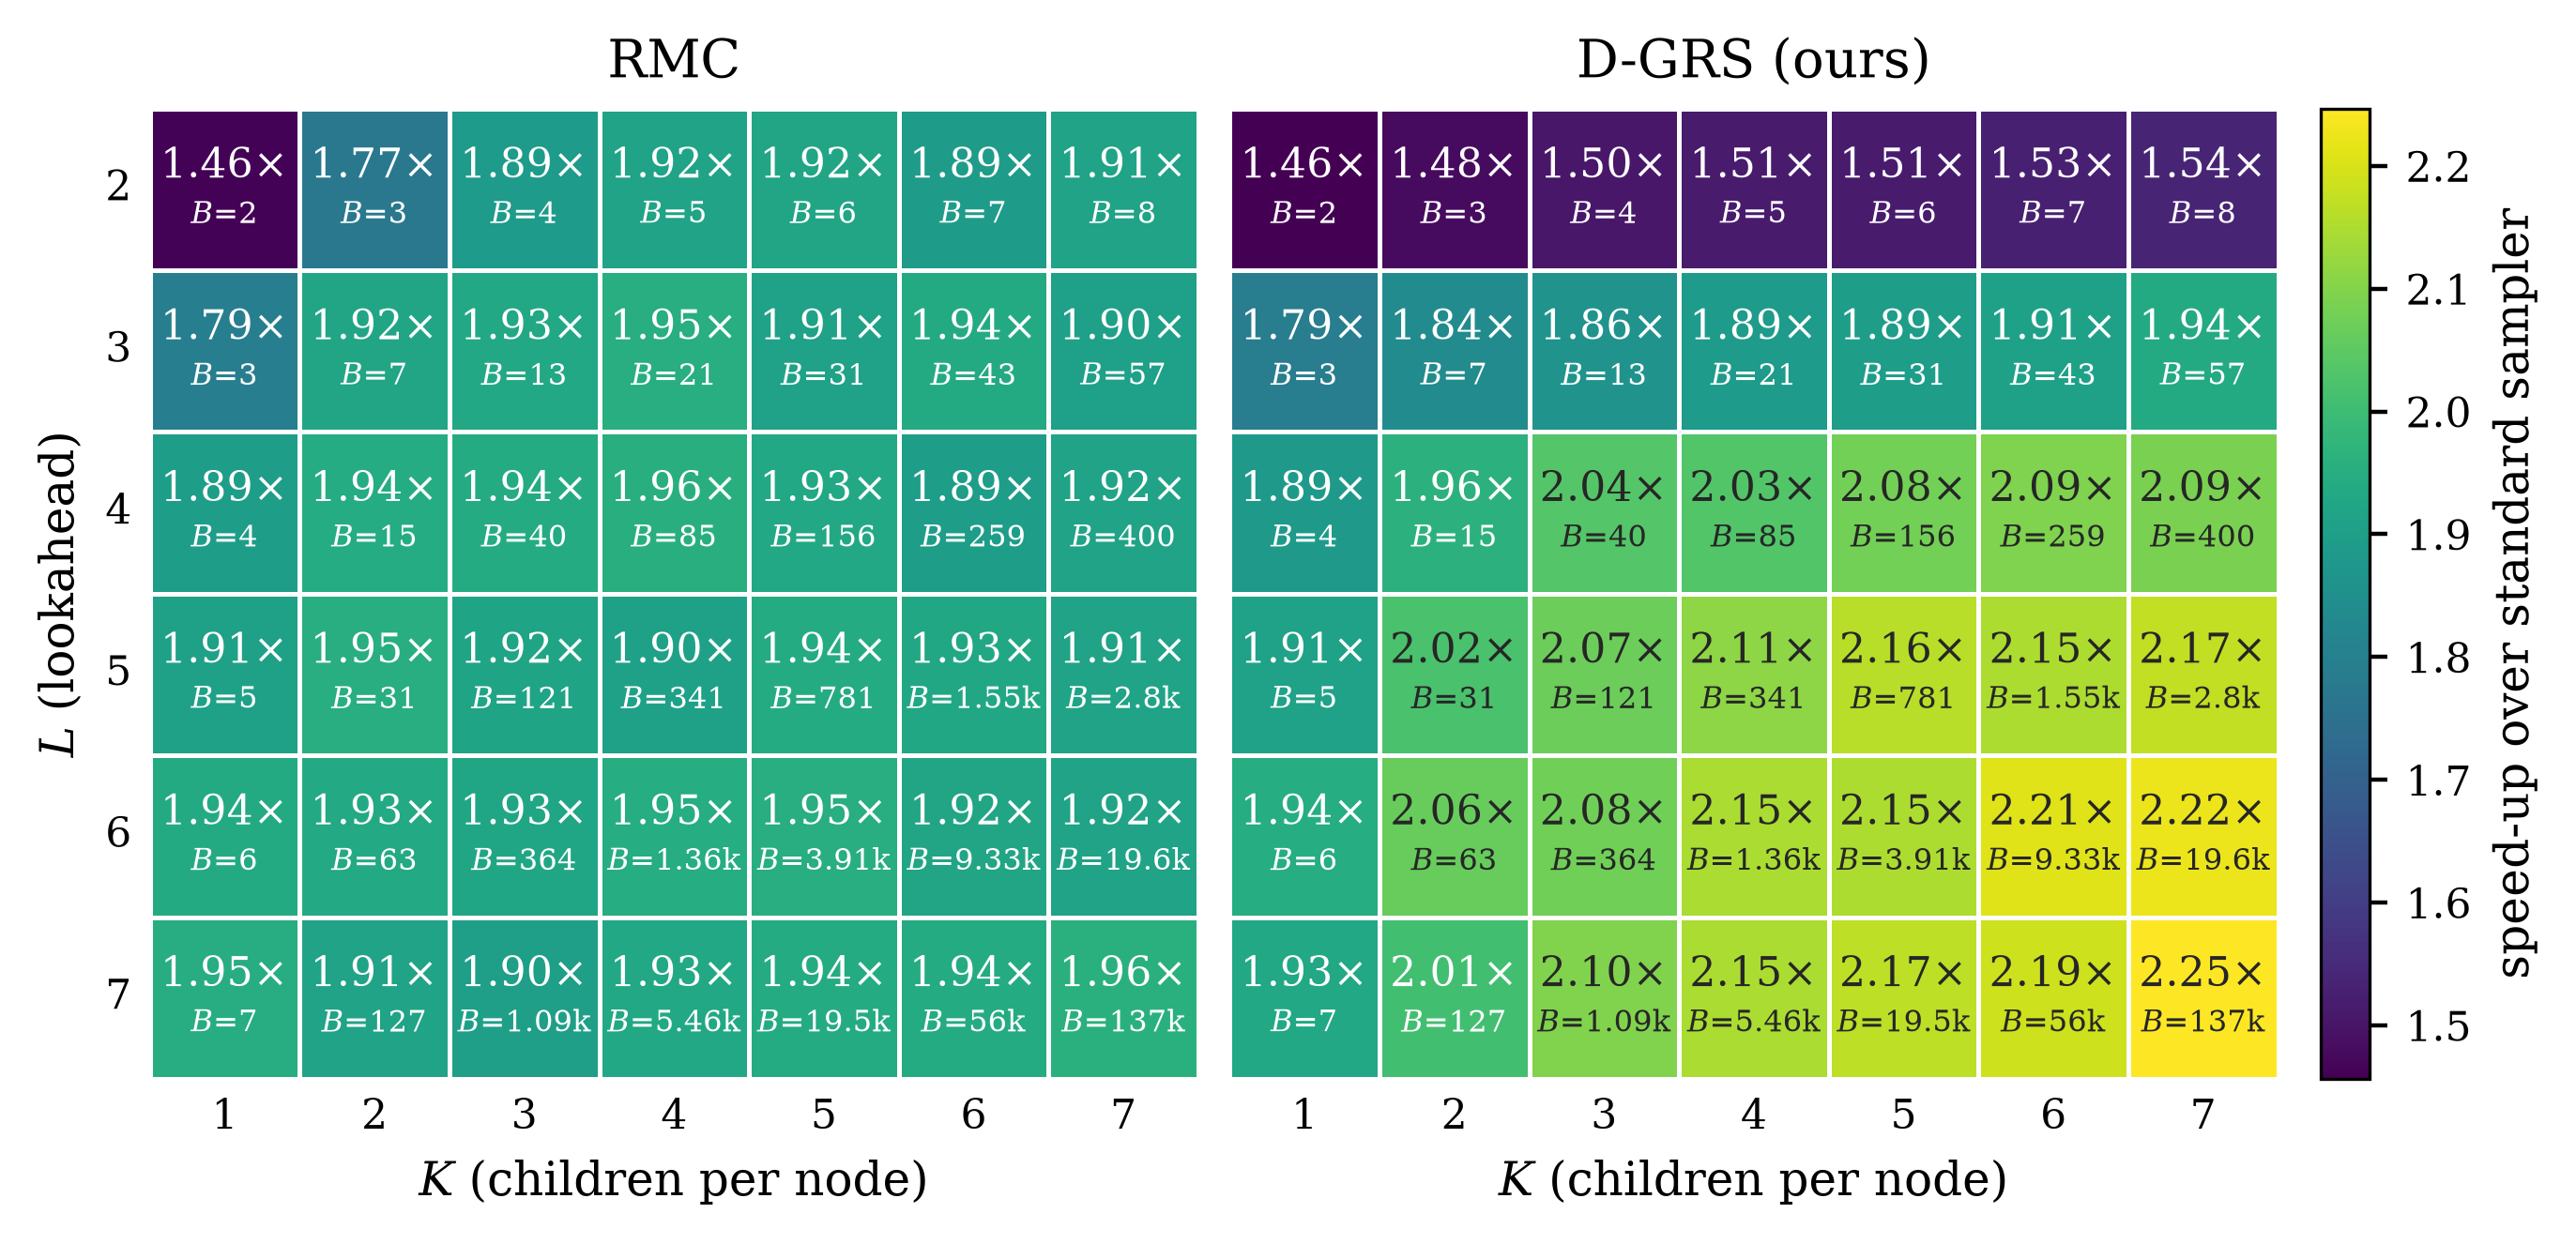

In [12]:
style = {
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "figure.dpi": 200,
}

with mpl.rc_context(style):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(6.75, 3.2),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    meshes = []

    for panel, (ax, rule) in enumerate(zip(axes, rules)):
        table = means[rule]
        values = table.to_numpy(dtype=float)

        sns.heatmap(
            table,
            ax=ax,
            annot=False,
            mask=~np.isfinite(values),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            linewidths=0.6,
            linecolor="white",
            cbar=False,
        )

        mesh = ax.collections[0]
        meshes.append(mesh)

        # Add mean speedup and budget as separately styled lines
        for (row, column), value in np.ndenumerate(values):
            if not np.isfinite(value):
                continue

            # Choose white or dark text according to cell brightness
            rgb = np.asarray(cmap(normalise(value))[:3])
            linear_rgb = np.where(
                rgb <= 0.03928,
                rgb / 12.92,
                ((rgb + 0.055) / 1.055) ** 2.4,
            )
            luminance = linear_rgb @ np.array([0.2126, 0.7152, 0.0722])
            text_color = "0.15" if luminance > 0.408 else "white"

            budget = budgets.iat[row, column]

            ax.text(
                column + 0.5,
                row + 0.36,
                f"{value:.2f}" + r"$\times$",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

            if pd.notna(budget):
                ax.text(
                    column + 0.5,
                    row + 0.66,
                    rf"$B$={compact_budget(budget)}",
                    ha="center",
                    va="center",
                    fontsize=5.8,
                    color=text_color,
                )

        ax.set_title(titles[rule], fontsize=10)
        ax.set_xlabel(r"$K$ (children per node)", fontsize=9)
        ax.set_ylabel(
            r"$L$ (lookahead)" if panel == 0 else "",
            fontsize=9,
        )

        ax.tick_params(
            labelsize=8,
            length=0,
            labelleft=(panel == 0),
        )

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

    # One shared colour bar
    colorbar = fig.colorbar(
        meshes[0],
        ax=list(axes),
        pad=0.02,
    )
    colorbar.set_label(
        "speed-up over standard sampler",
        fontsize=9,
    )
    colorbar.ax.tick_params(labelsize=8)
    colorbar.outline.set_linewidth(0.6)

    plt.show()

## Gaussian-mixture experiment (`gm-picard-sweep`)

In [23]:
def load_csv_group(filename: str) -> pd.DataFrame:
    frames = []
    for path in sorted((RESULTS_DIR / "gm-picard-sweep").glob(f"*/**/{filename}")):
        frame = pd.read_csv(path)
        frame.insert(0, "source_run", path.parent.name)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()



gm_trajectories = load_csv_group("trajectories.csv")
gm_trajectories = gm_trajectories.query("K <= 6 and L <= 6").copy()
# gm_raw.drop(columns=["chain_depth", "target_rows"], inplace=True)
# gm_raw.rename(columns={"replicate": "sample_idx"}, inplace=True)

# # Compute average speedup and standard deviation of speedup for each combination of K and L
# gm_raw["speedup"] = gm_raw["num_steps"] / gm_raw["target_calls"]
# gm_raw["acceptance_rate"] = gm_raw["accepted_depth"] / gm_raw["num_steps"]

# # gm_summary = load_csv_group("summary.csv")
# # Create summary dataframe
# gm_summary = (
#     gm_raw.groupby(["K", "L", "rule"], as_index=False)
#       .agg(
#           speedup_mean=("speedup", "mean"),
#           speedup_std=("speedup", "std"),
#           acceptance_rate_mean=("acceptance_rate", "mean"),
#           acceptance_rate_std=("acceptance_rate", "std"),
#           NFE_mean=("target_calls", "mean"),
#           NFE_std=("target_calls", "std"),
#           round_mean=("rounds", "mean"),
#           round_std=("rounds", "std"),
#           accepted_depth_mean=("accepted_depth", "mean"),
#           accepted_depth_std=("accepted_depth", "std"),
#           num_samples=("sample_idx", "count"),
#           verification_budget=("verification_budget", "first"),
#           B=("B", "first")
#       )
# )

# print(f"gm_raw:     {gm_raw.shape[0]:,} rows × {gm_raw.shape[1]:,} columns")
# print(f"gm_summary: {gm_summary.shape[0]:,} rows × {gm_summary.shape[1]:,} columns")
# display(gm_raw)
# print("-" * 173)
# display(gm_summary)

In [24]:
gm_trajectories

,source_run,trajectory_id,eps,rule,K,L,J,replicate,match,evaluate_leaves,...,end_to_end_speedup,initial_l2,initial_mean,initial_std,sample_l2,sample_mean,sample_std,sample_min,sample_max,sampling_seconds
0,J0,eps0.1-rmc-K1_L1-J0-r000000,0.1,rmc,1,1,0,0,verification,0,...,0.967742,23.986388,-0.045455,1.059084,26.243739,0.017243,1.159692,-2.154481,2.214868,0.012173
1,J0,eps0.1-d_grs-K1_L1-J0-r000000,0.1,d-grs,1,1,0,0,verification,0,...,0.967742,23.986388,-0.045455,1.059084,26.350084,0.016976,1.164396,-2.184010,2.177978,0.011348
2,J0,eps0.1-rmc-K1_L1-J0-r000001,0.1,rmc,1,1,0,1,verification,0,...,0.967742,22.459619,0.069957,0.990116,26.287704,0.007006,1.161742,-2.095276,2.159393,0.012350
3,J0,eps0.1-d_grs-K1_L1-J0-r000001,0.1,d-grs,1,1,0,1,verification,0,...,0.967742,22.459619,0.069957,0.990116,26.204198,0.006645,1.158054,-2.097645,2.151224,0.011628
4,J0,eps0.1-rmc-K1_L1-J0-r000002,0.1,rmc,1,1,0,2,verification,0,...,0.967742,23.353550,0.018971,1.031916,26.194916,0.018165,1.157520,-2.243758,2.282988,0.012446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194395,eps0.6,eps0.6-d_grs-K6_L6-J6-r000097,0.6,d-grs,6,6,6,97,verification,0,...,0.909091,21.650334,0.049160,0.955555,26.381389,-0.000965,1.165903,-2.220383,2.337351,33.359585
194396,eps0.6,eps0.6-rmc-K6_L6-J6-r000098,0.6,rmc,6,6,6,98,verification,0,...,1.875000,21.221945,0.072517,0.935079,27.130385,-0.108167,1.194116,-2.407740,2.433561,0.236878
194397,eps0.6,eps0.6-d_grs-K6_L6-J6-r000098,0.6,d-grs,6,6,6,98,verification,0,...,0.909091,21.221945,0.072517,0.935079,26.342396,0.016285,1.164067,-2.093955,2.420185,33.403572
194398,eps0.6,eps0.6-rmc-K6_L6-J6-r000099,0.6,rmc,6,6,6,99,verification,0,...,1.764706,22.202973,0.012543,0.981162,26.265903,0.023590,1.160560,-2.170070,2.173487,0.230366


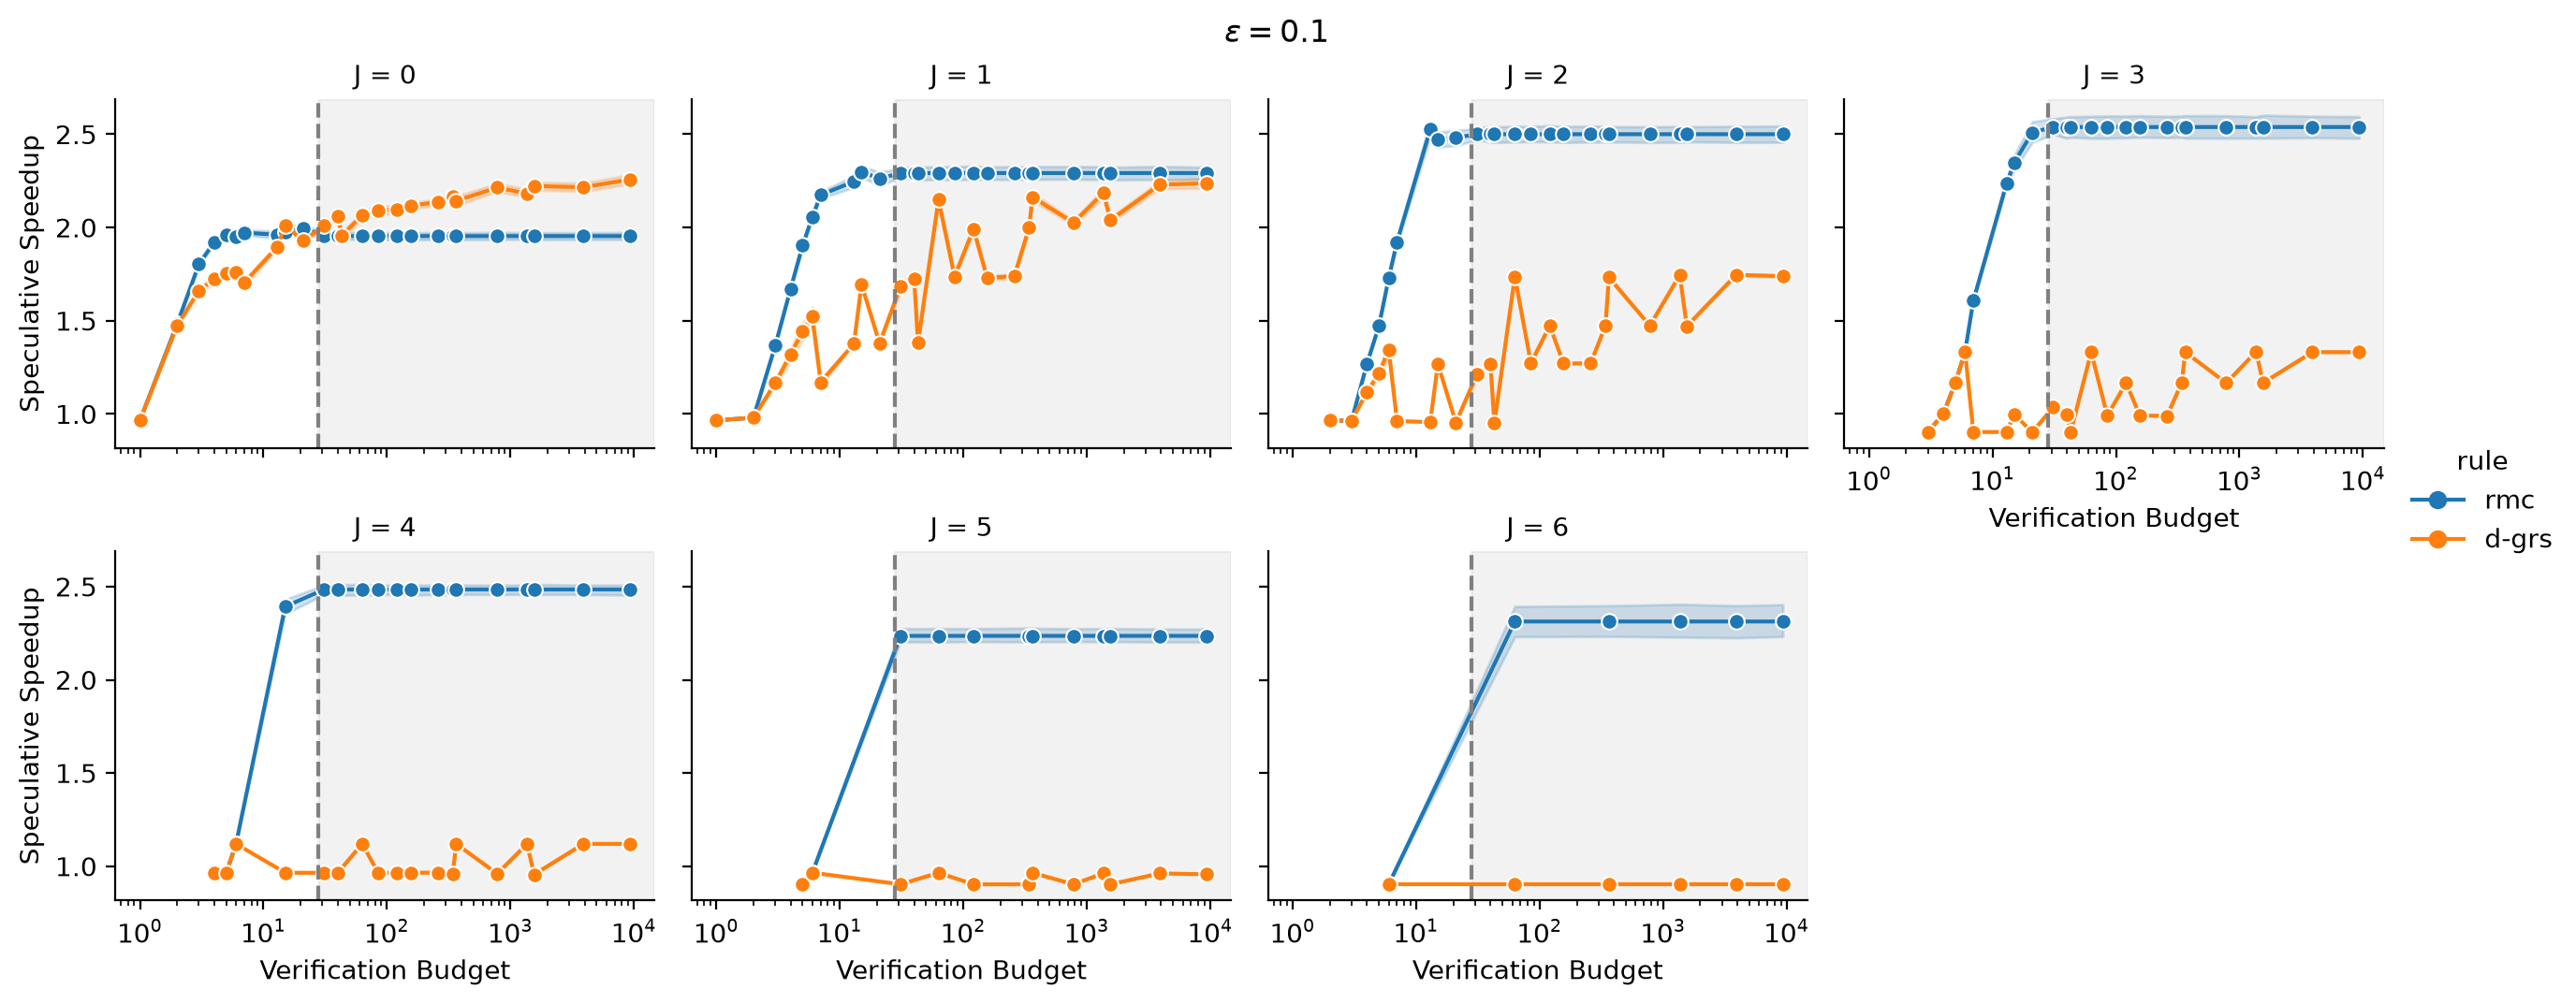

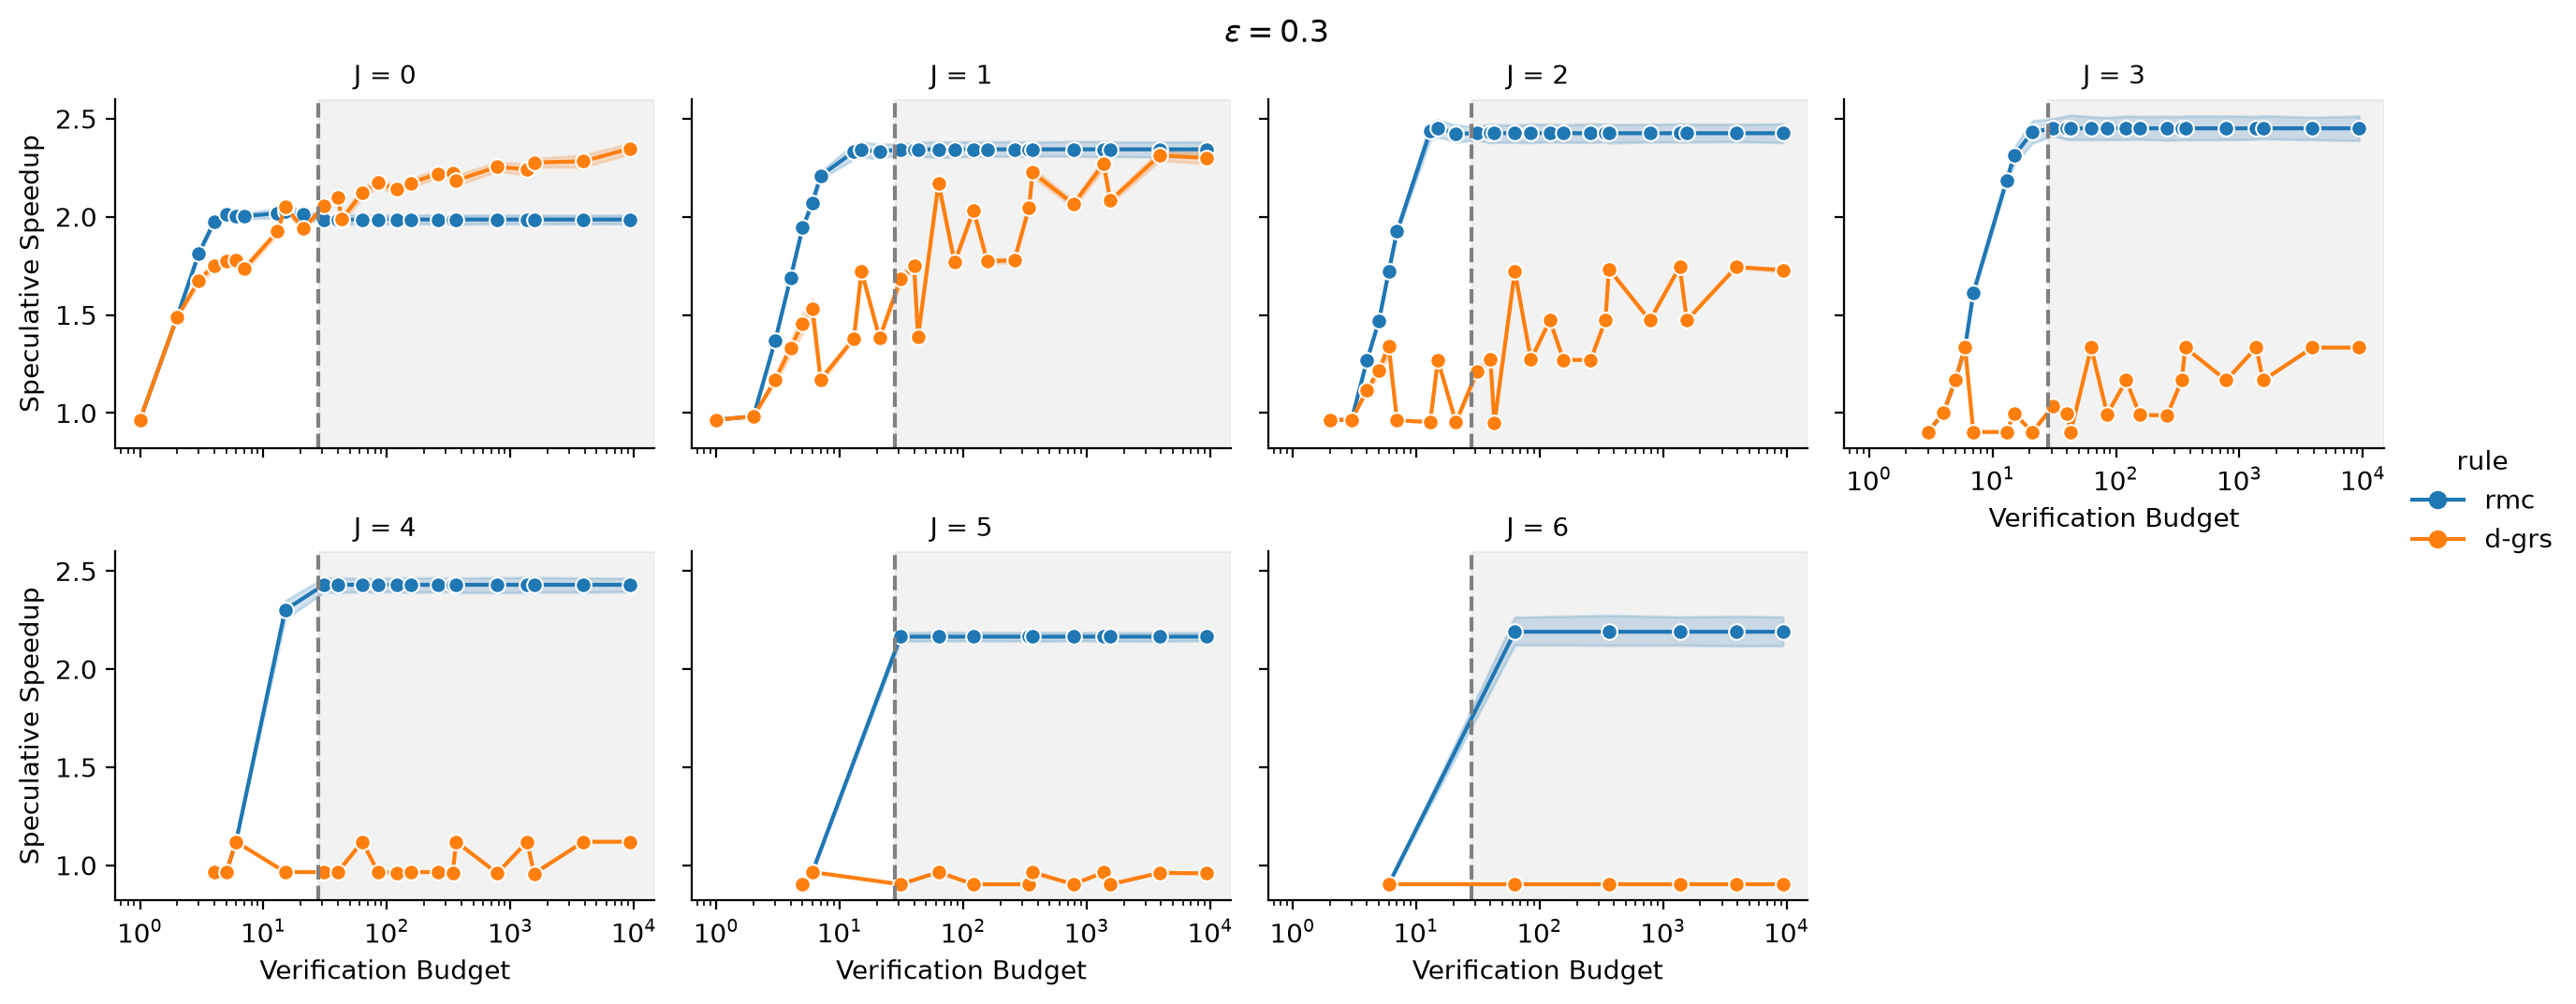

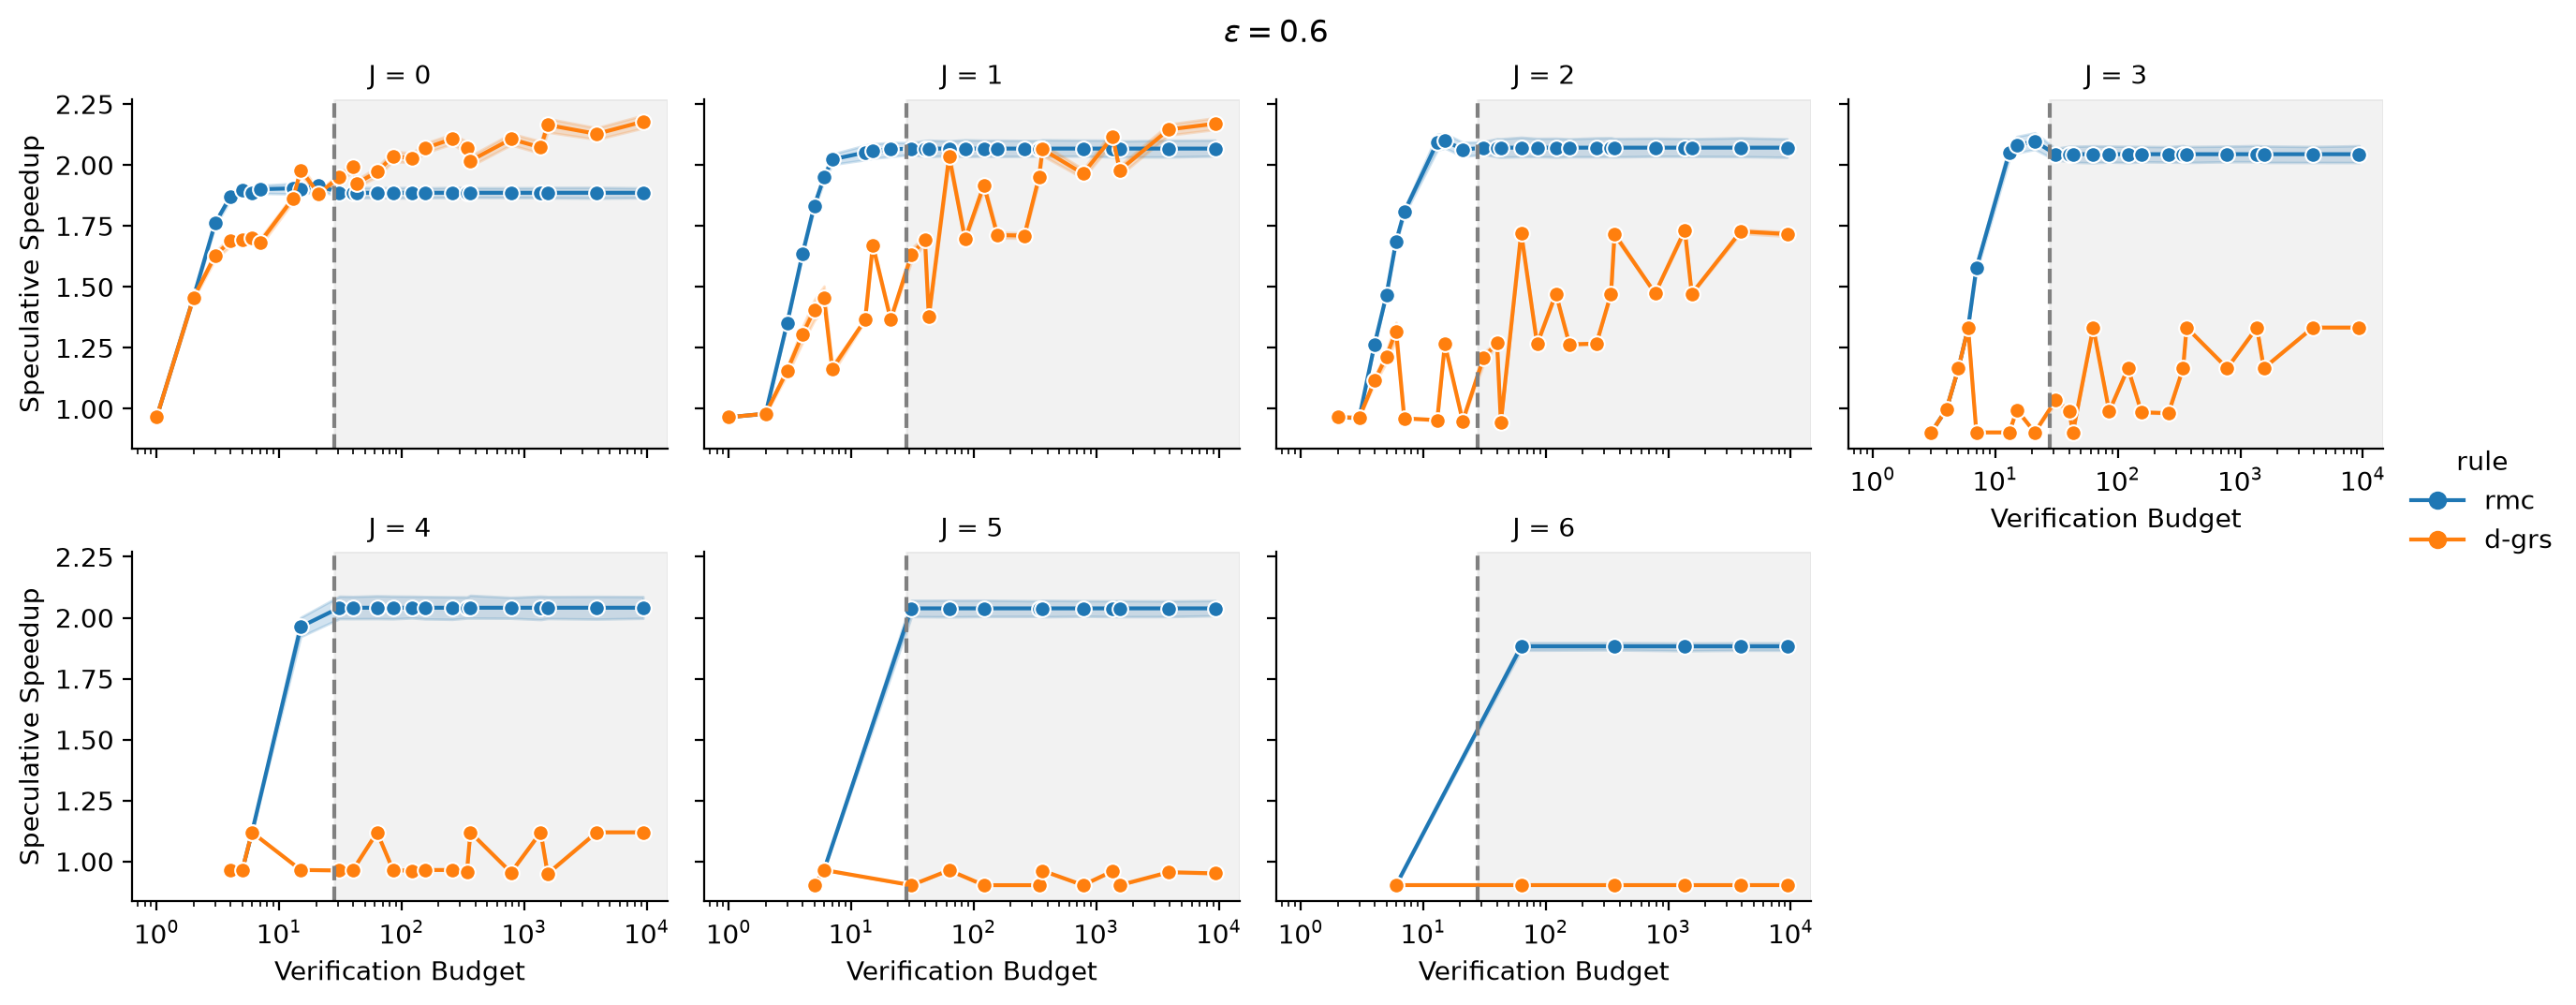

In [31]:
eps = 0.1
g=sns.relplot(
    data=gm_trajectories[gm_trajectories["eps"]==eps], 
    x="allocated_verification_budget", 
    y="speculative_speedup", 
    hue="rule", 
    #row="eps",
    col="J",
    col_wrap=4,
    marker="o",
    kind="line",
    height=2.7,
    aspect=1.2
)
g.set(xscale="log")

for ax in g.axes.flat:
    xmin, xmax = ax.get_xlim()
    ax.axvline(28, color="gray", linestyle="--")
    if xmax > 28:
        ax.axvspan(28, xmax, color="gray", alpha=0.1)
    ax.set_xlim(xmin, xmax)

    ax.set_ylabel("Speculative Speedup")
    ax.set_xlabel("Verification Budget")

g.fig.suptitle(r"$\epsilon={}$".format(eps), fontsize=12)
g.fig.subplots_adjust(top=0.90)
plt.show()

eps = 0.3
g=sns.relplot(
    data=gm_trajectories[gm_trajectories["eps"]==eps], 
    x="allocated_verification_budget", 
    y="speculative_speedup", 
    hue="rule", 
    #row="eps",
    col="J",
    col_wrap=4,
    marker="o",
    kind="line",
    height=2.7,
    aspect=1.2
)
g.set(xscale="log")

for ax in g.axes.flat:
    xmin, xmax = ax.get_xlim()
    ax.axvline(28, color="gray", linestyle="--")
    if xmax > 28:
        ax.axvspan(28, xmax, color="gray", alpha=0.1)
    ax.set_xlim(xmin, xmax)

    ax.set_ylabel("Speculative Speedup")
    ax.set_xlabel("Verification Budget")

g.fig.suptitle(r"$\epsilon={}$".format(eps), fontsize=12)
g.fig.subplots_adjust(top=0.90)
plt.show()

eps = 0.6
g=sns.relplot(
    data=gm_trajectories[gm_trajectories["eps"]==eps], 
    x="allocated_verification_budget", 
    y="speculative_speedup", 
    hue="rule", 
    #row="eps",
    col="J",
    col_wrap=4,
    marker="o",
    kind="line",
    height=2.7,
    aspect=1.2
)
g.set(xscale="log")

for ax in g.axes.flat:
    xmin, xmax = ax.get_xlim()
    ax.axvline(28, color="gray", linestyle="--")
    if xmax > 28:
        ax.axvspan(28, xmax, color="gray", alpha=0.1)
    ax.set_xlim(xmin, xmax)

    ax.set_ylabel("Speculative Speedup")
    ax.set_xlabel("Verification Budget")

g.fig.suptitle(r"$\epsilon={}$".format(eps), fontsize=12)
g.fig.subplots_adjust(top=0.90)
plt.show()

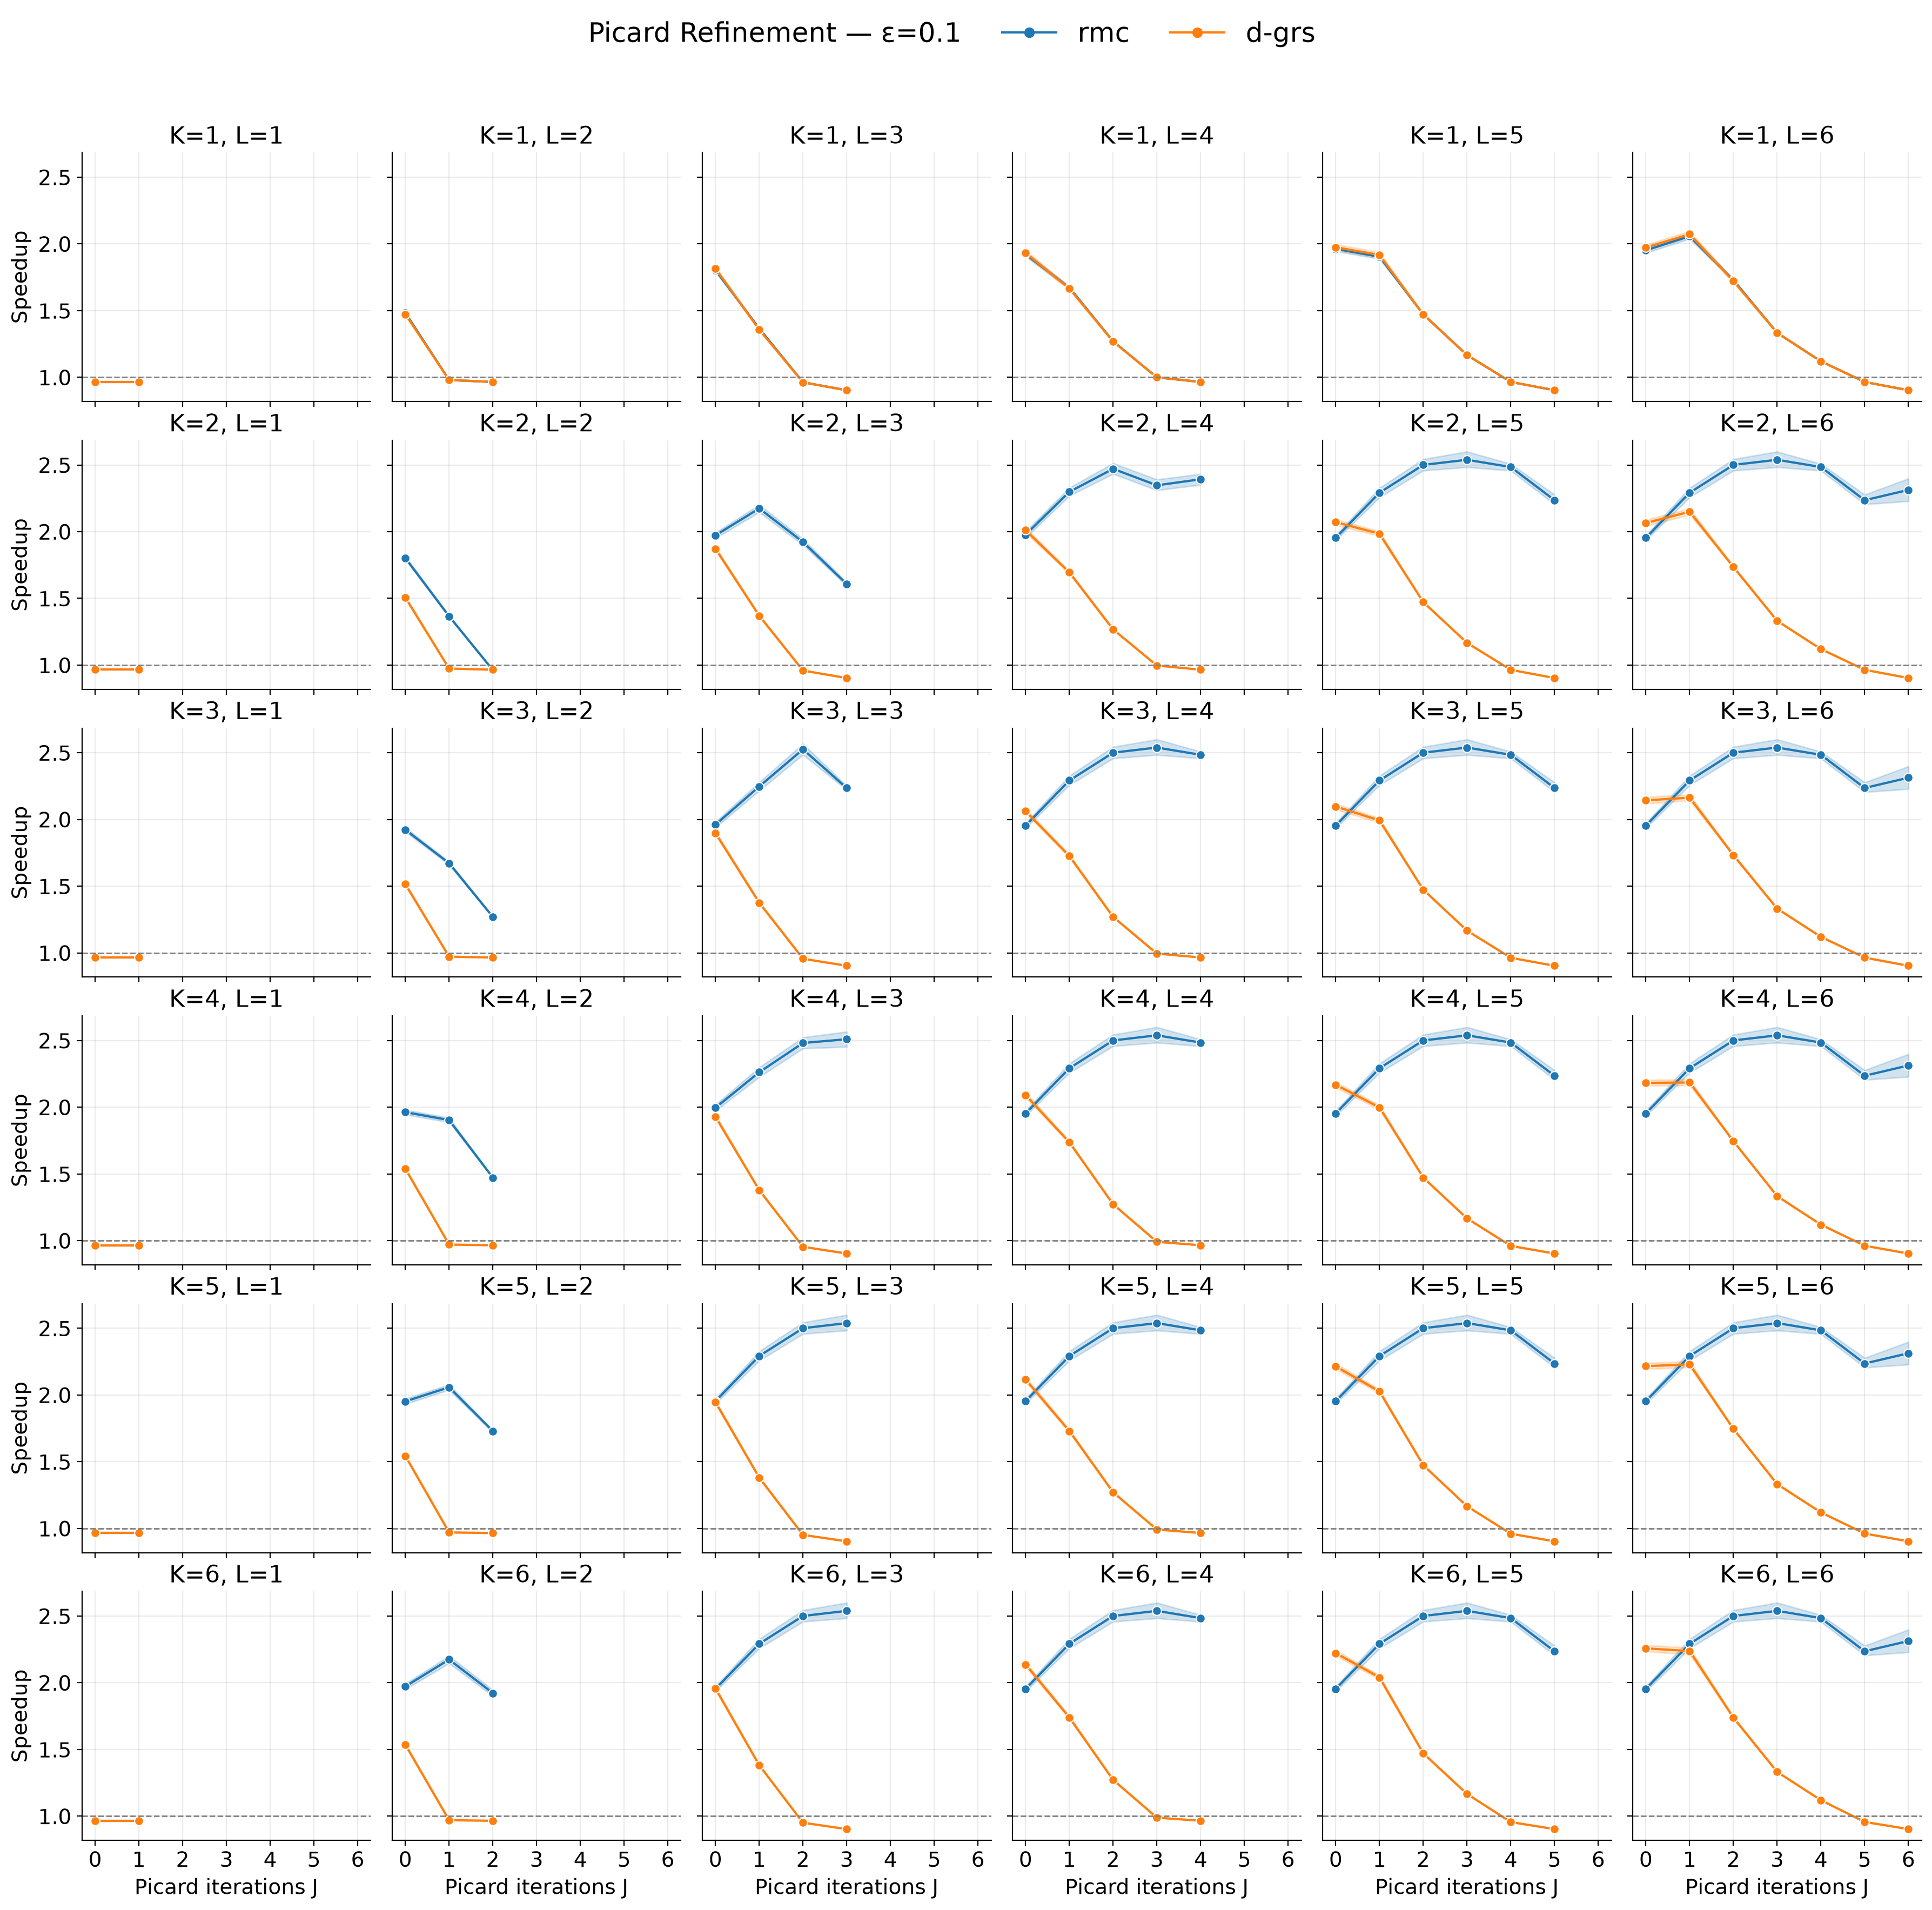

In [26]:
from matplotlib.lines import Line2D


eps = 0.1

df = gm_trajectories.loc[
    gm_trajectories["eps"].eq(eps)
].copy()

# Avoid counting the same trajectory from multiple output files.
#df = df.drop_duplicates("trajectory_id")

# Order panels numerically by K, then L.
pairs = (
    df[["K", "L"]]
    .drop_duplicates()
    .sort_values(["K", "L"])
)
panel_order = [
    f"K={int(K)}, L={int(L)}"
    for K, L in pairs.itertuples(index=False, name=None)
]
df["topology"] = [
    f"K={int(K)}, L={int(L)}"
    for K, L in zip(df["K"], df["L"])
]

g = sns.relplot(
    data=df,
    x="J",
    y="speculative_speedup",
    hue="rule",
    hue_order=["rmc", "d-grs"],
    col="topology",
    col_order=panel_order,
    col_wrap=6,
    kind="line",
    marker="o",
    estimator="mean",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=42,
    height=3,
    aspect=1.,
    facet_kws={"sharex": True, "sharey": True},

)

g.set_titles("{col_name}", size=16)
g.set_axis_labels("Picard iterations J", "Speedup", fontsize=14)

for ax in g.axes.flat:
    ax.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(sorted(df["J"].unique()))
    ax.grid(alpha=0.25)
    ax.tick_params(axis="both", labelsize=14)

handles = g.legend.legend_handles
labels = [text.get_text() for text in g.legend.get_texts()]
g.legend.remove()

if g.figure._suptitle is not None:
    g.figure._suptitle.remove()

g.figure.subplots_adjust(top=0.90)

header = Line2D([], [], linestyle="none", marker="")

g.figure.legend(
    [header, *handles],
    [f"Picard Refinement — ε={eps}", *labels],
    loc="upper center",
    bbox_to_anchor=(0.45, 0.98),
    ncol=len(labels) + 1,
    frameon=False,
    fontsize=18,
    columnspacing=1.5,
)

plt.show()

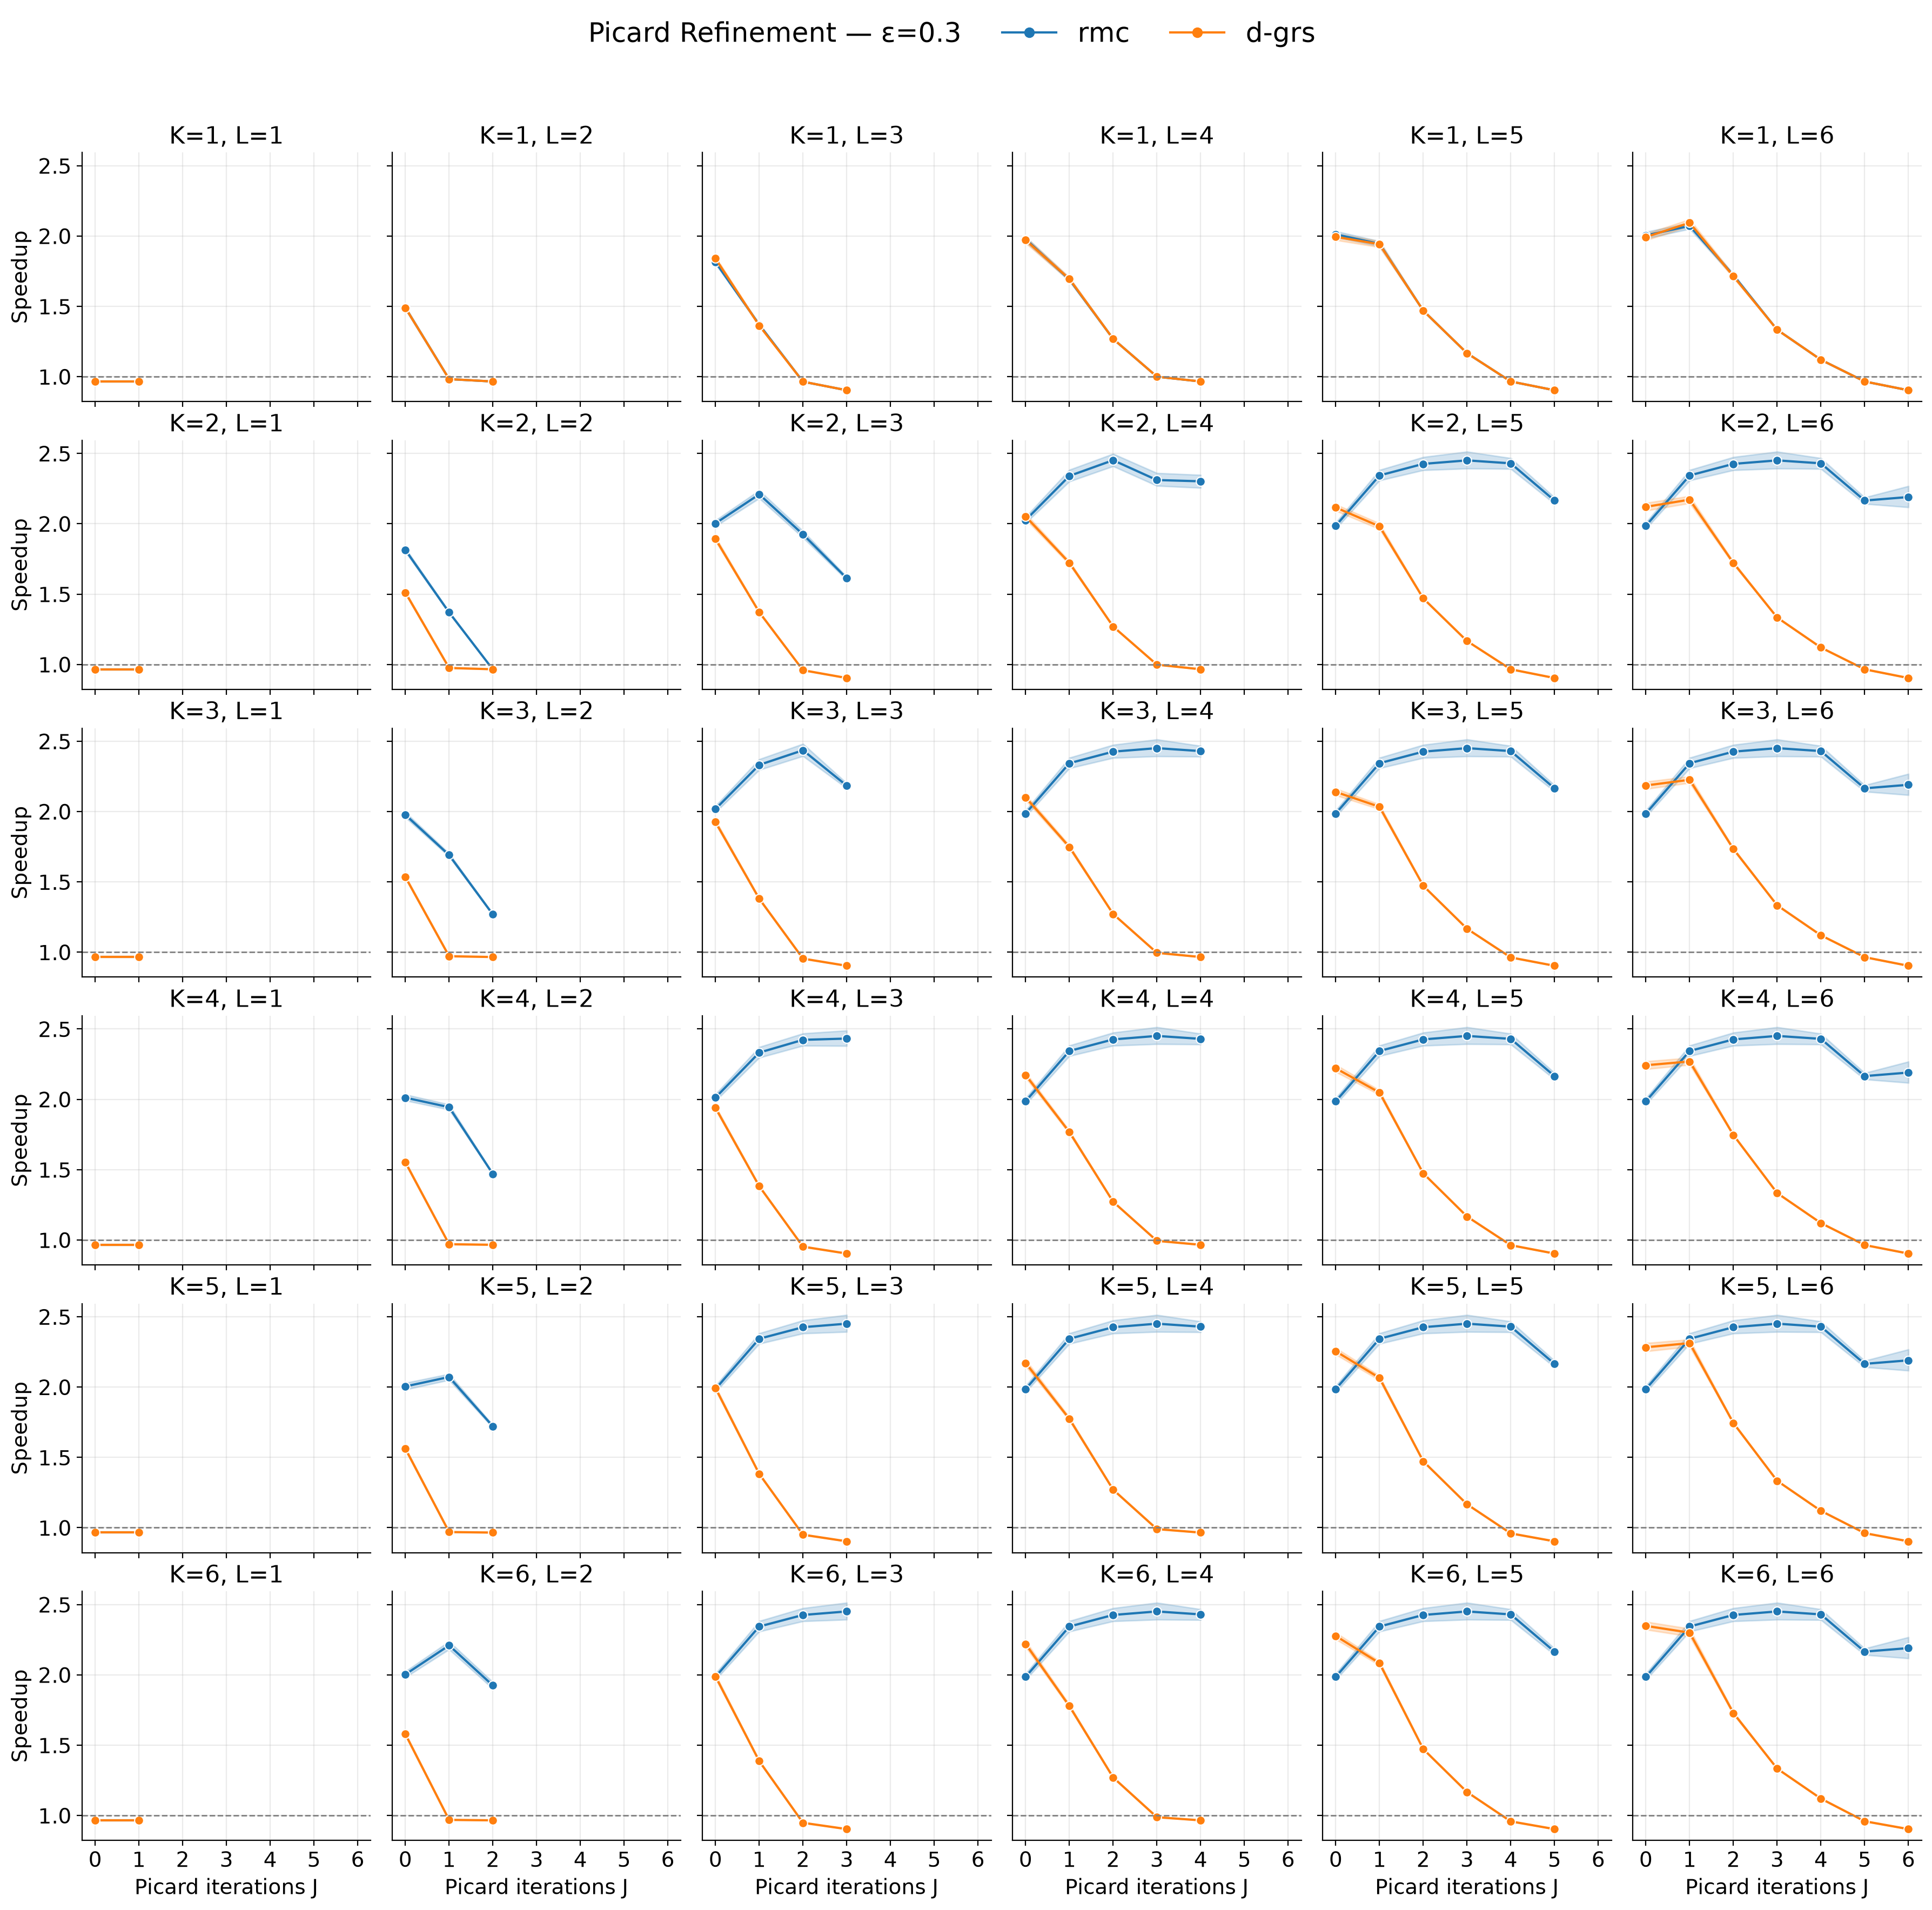

In [27]:
from matplotlib.lines import Line2D


eps = 0.3

df = gm_trajectories.loc[
    gm_trajectories["eps"].eq(eps)
].copy()

# Avoid counting the same trajectory from multiple output files.
#df = df.drop_duplicates("trajectory_id")

# Order panels numerically by K, then L.
pairs = (
    df[["K", "L"]]
    .drop_duplicates()
    .sort_values(["K", "L"])
)
panel_order = [
    f"K={int(K)}, L={int(L)}"
    for K, L in pairs.itertuples(index=False, name=None)
]
df["topology"] = [
    f"K={int(K)}, L={int(L)}"
    for K, L in zip(df["K"], df["L"])
]

g = sns.relplot(
    data=df,
    x="J",
    y="speculative_speedup",
    hue="rule",
    hue_order=["rmc", "d-grs"],
    col="topology",
    col_order=panel_order,
    col_wrap=6,
    kind="line",
    marker="o",
    estimator="mean",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=42,
    height=3,
    aspect=1.,
    facet_kws={"sharex": True, "sharey": True},

)

g.set_titles("{col_name}", size=16)
g.set_axis_labels("Picard iterations J", "Speedup", fontsize=14)

for ax in g.axes.flat:
    ax.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(sorted(df["J"].unique()))
    ax.grid(alpha=0.25)
    ax.tick_params(axis="both", labelsize=14)

handles = g.legend.legend_handles
labels = [text.get_text() for text in g.legend.get_texts()]
g.legend.remove()

if g.figure._suptitle is not None:
    g.figure._suptitle.remove()

g.figure.subplots_adjust(top=0.90)

header = Line2D([], [], linestyle="none", marker="")

g.figure.legend(
    [header, *handles],
    [f"Picard Refinement — ε={eps}", *labels],
    loc="upper center",
    bbox_to_anchor=(0.45, 0.98),
    ncol=len(labels) + 1,
    frameon=False,
    fontsize=18,
    columnspacing=1.5,
)

plt.show()

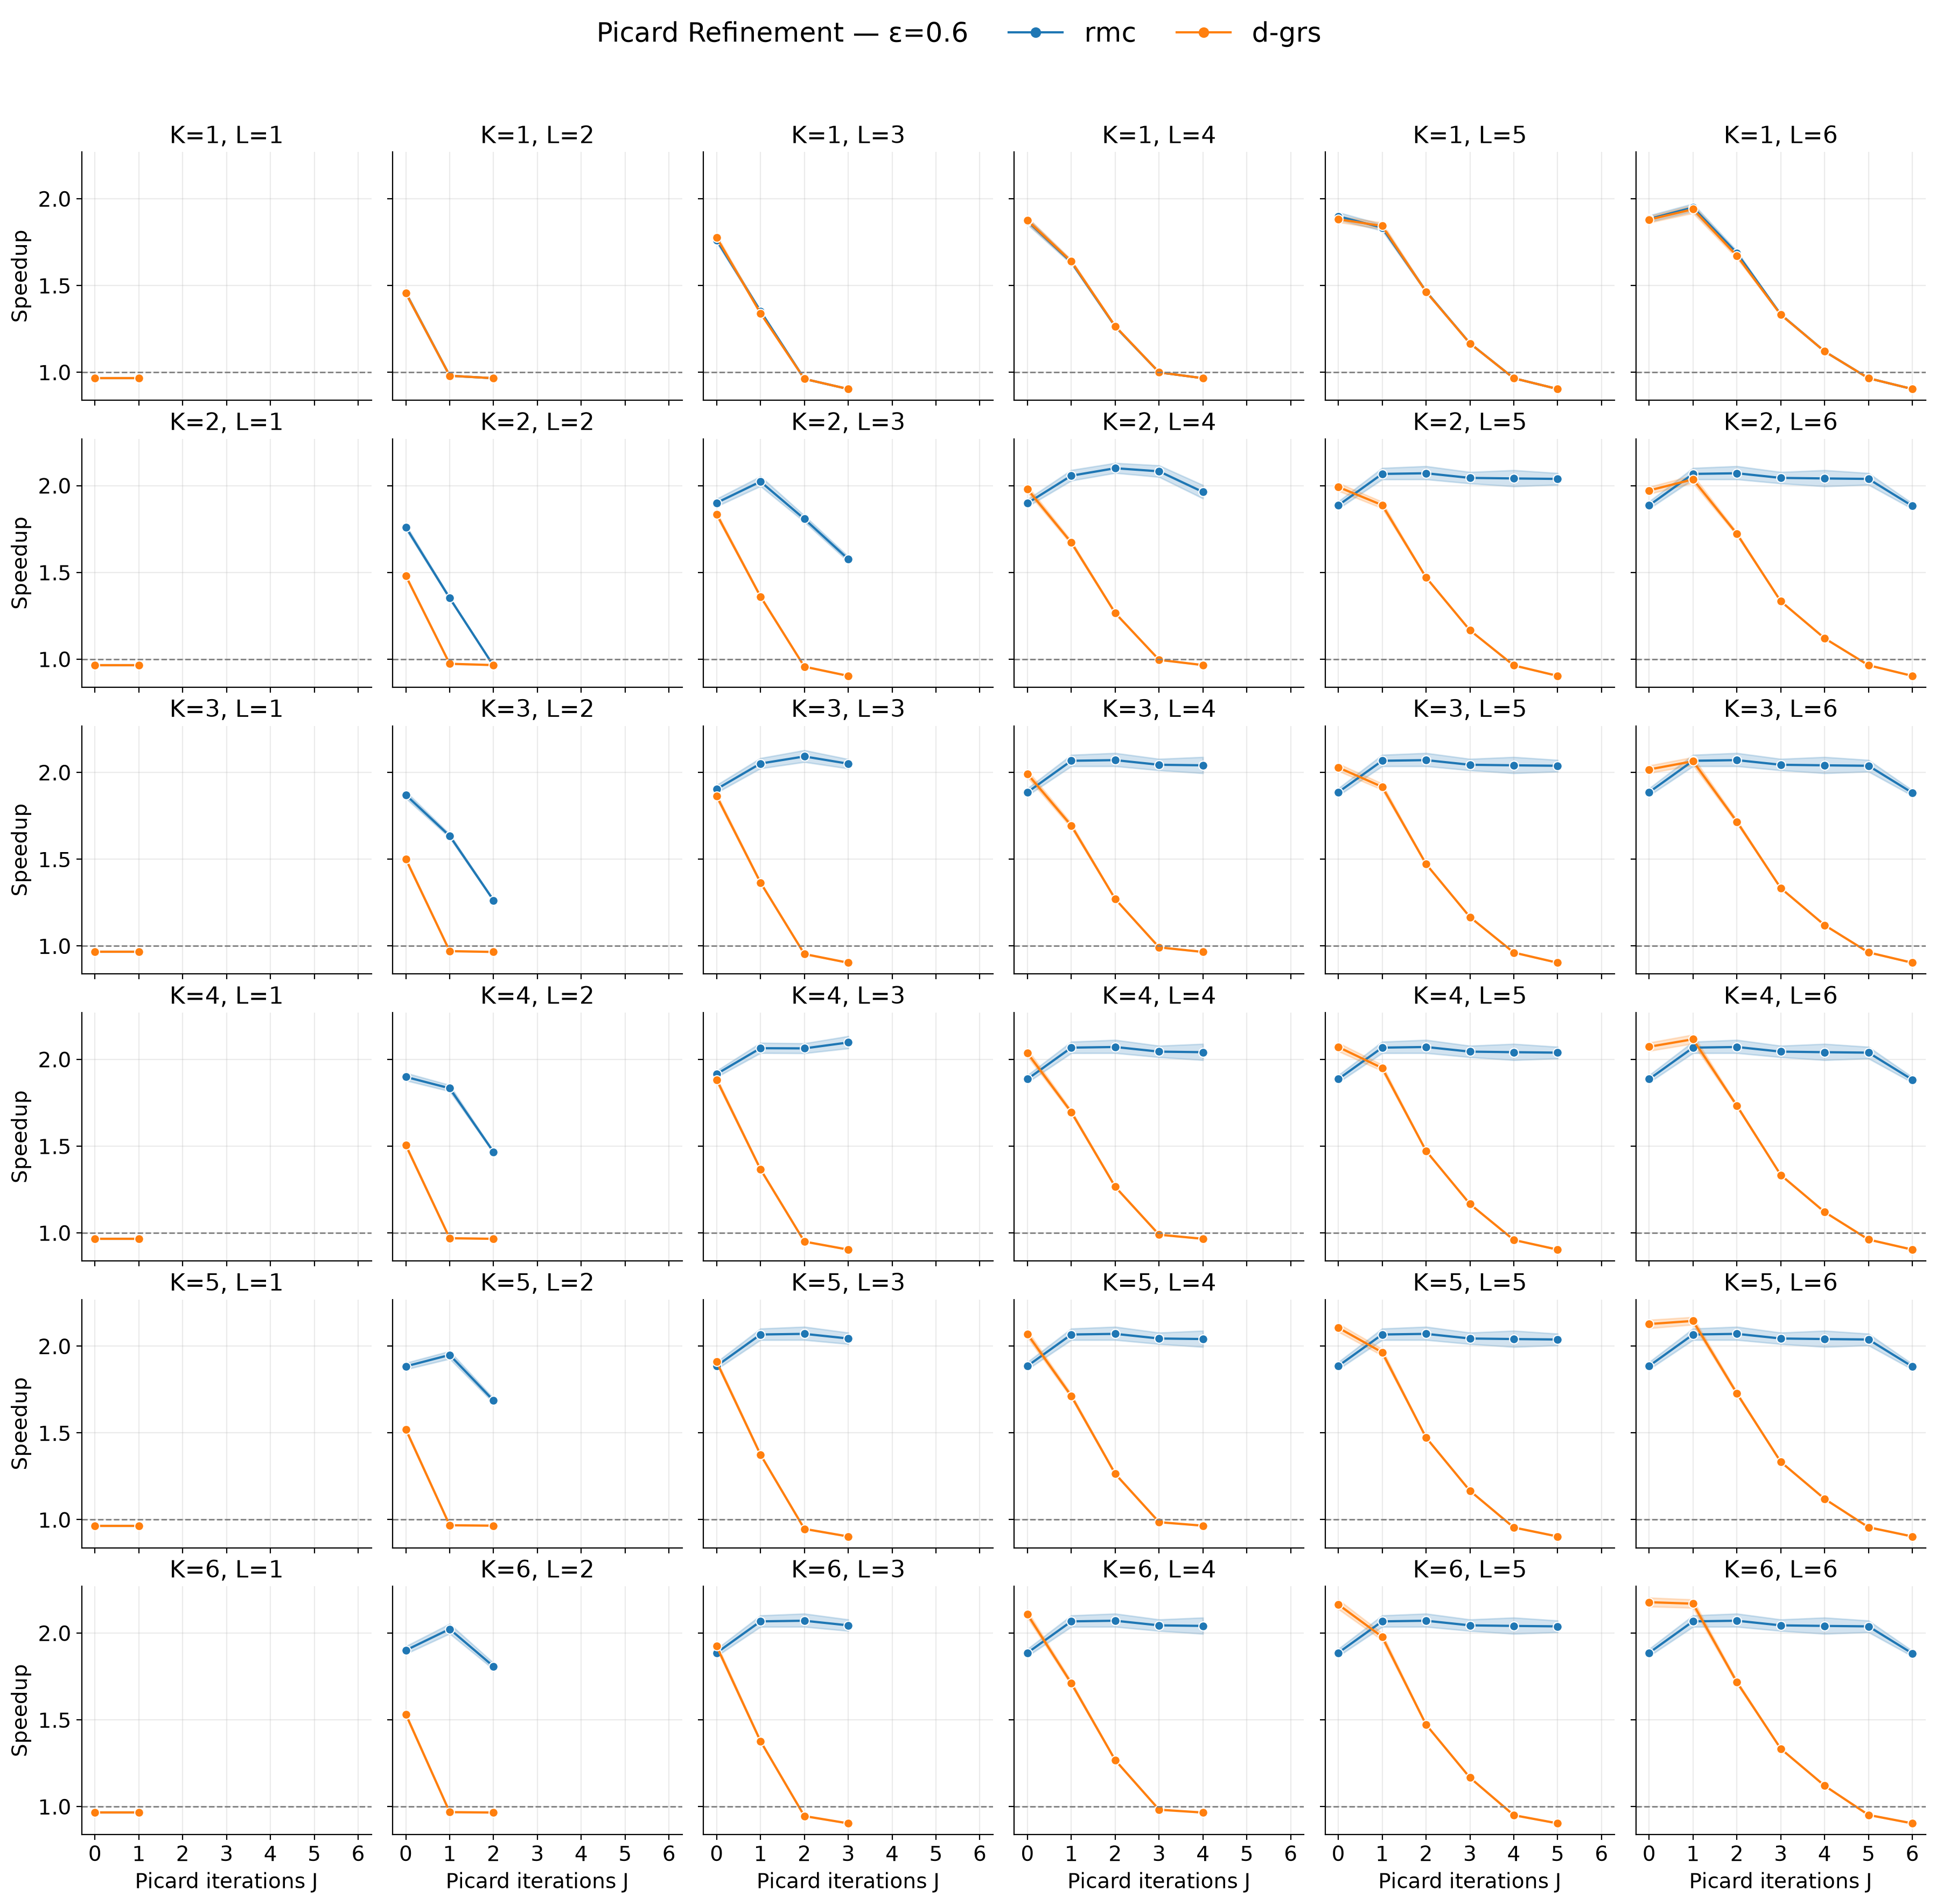

In [28]:
from matplotlib.lines import Line2D

eps = 0.6

df = gm_trajectories.loc[
    gm_trajectories["eps"].eq(eps)
].copy()

# Avoid counting the same trajectory from multiple output files.
#df = df.drop_duplicates("trajectory_id")

# Order panels numerically by K, then L.
pairs = (
    df[["K", "L"]]
    .drop_duplicates()
    .sort_values(["K", "L"])
)
panel_order = [
    f"K={int(K)}, L={int(L)}"
    for K, L in pairs.itertuples(index=False, name=None)
]
df["topology"] = [
    f"K={int(K)}, L={int(L)}"
    for K, L in zip(df["K"], df["L"])
]

g = sns.relplot(
    data=df,
    x="J",
    y="speculative_speedup",
    hue="rule",
    hue_order=["rmc", "d-grs"],
    col="topology",
    col_order=panel_order,
    col_wrap=6,
    kind="line",
    marker="o",
    estimator="mean",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=42,
    height=3,
    aspect=1.,
    facet_kws={"sharex": True, "sharey": True},

)

g.set_titles("{col_name}", size=16)
g.set_axis_labels("Picard iterations J", "Speedup", fontsize=14)

for ax in g.axes.flat:
    ax.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(sorted(df["J"].unique()))
    ax.grid(alpha=0.25)
    ax.tick_params(axis="both", labelsize=14)

handles = g.legend.legend_handles
labels = [text.get_text() for text in g.legend.get_texts()]
g.legend.remove()

if g.figure._suptitle is not None:
    g.figure._suptitle.remove()

g.figure.subplots_adjust(top=0.90)

header = Line2D([], [], linestyle="none", marker="")

g.figure.legend(
    [header, *handles],
    [f"Picard Refinement — ε={eps}", *labels],
    loc="upper center",
    bbox_to_anchor=(0.45, 0.98),
    ncol=len(labels) + 1,
    frameon=False,
    fontsize=18,
    columnspacing=1.5,
)

plt.show()

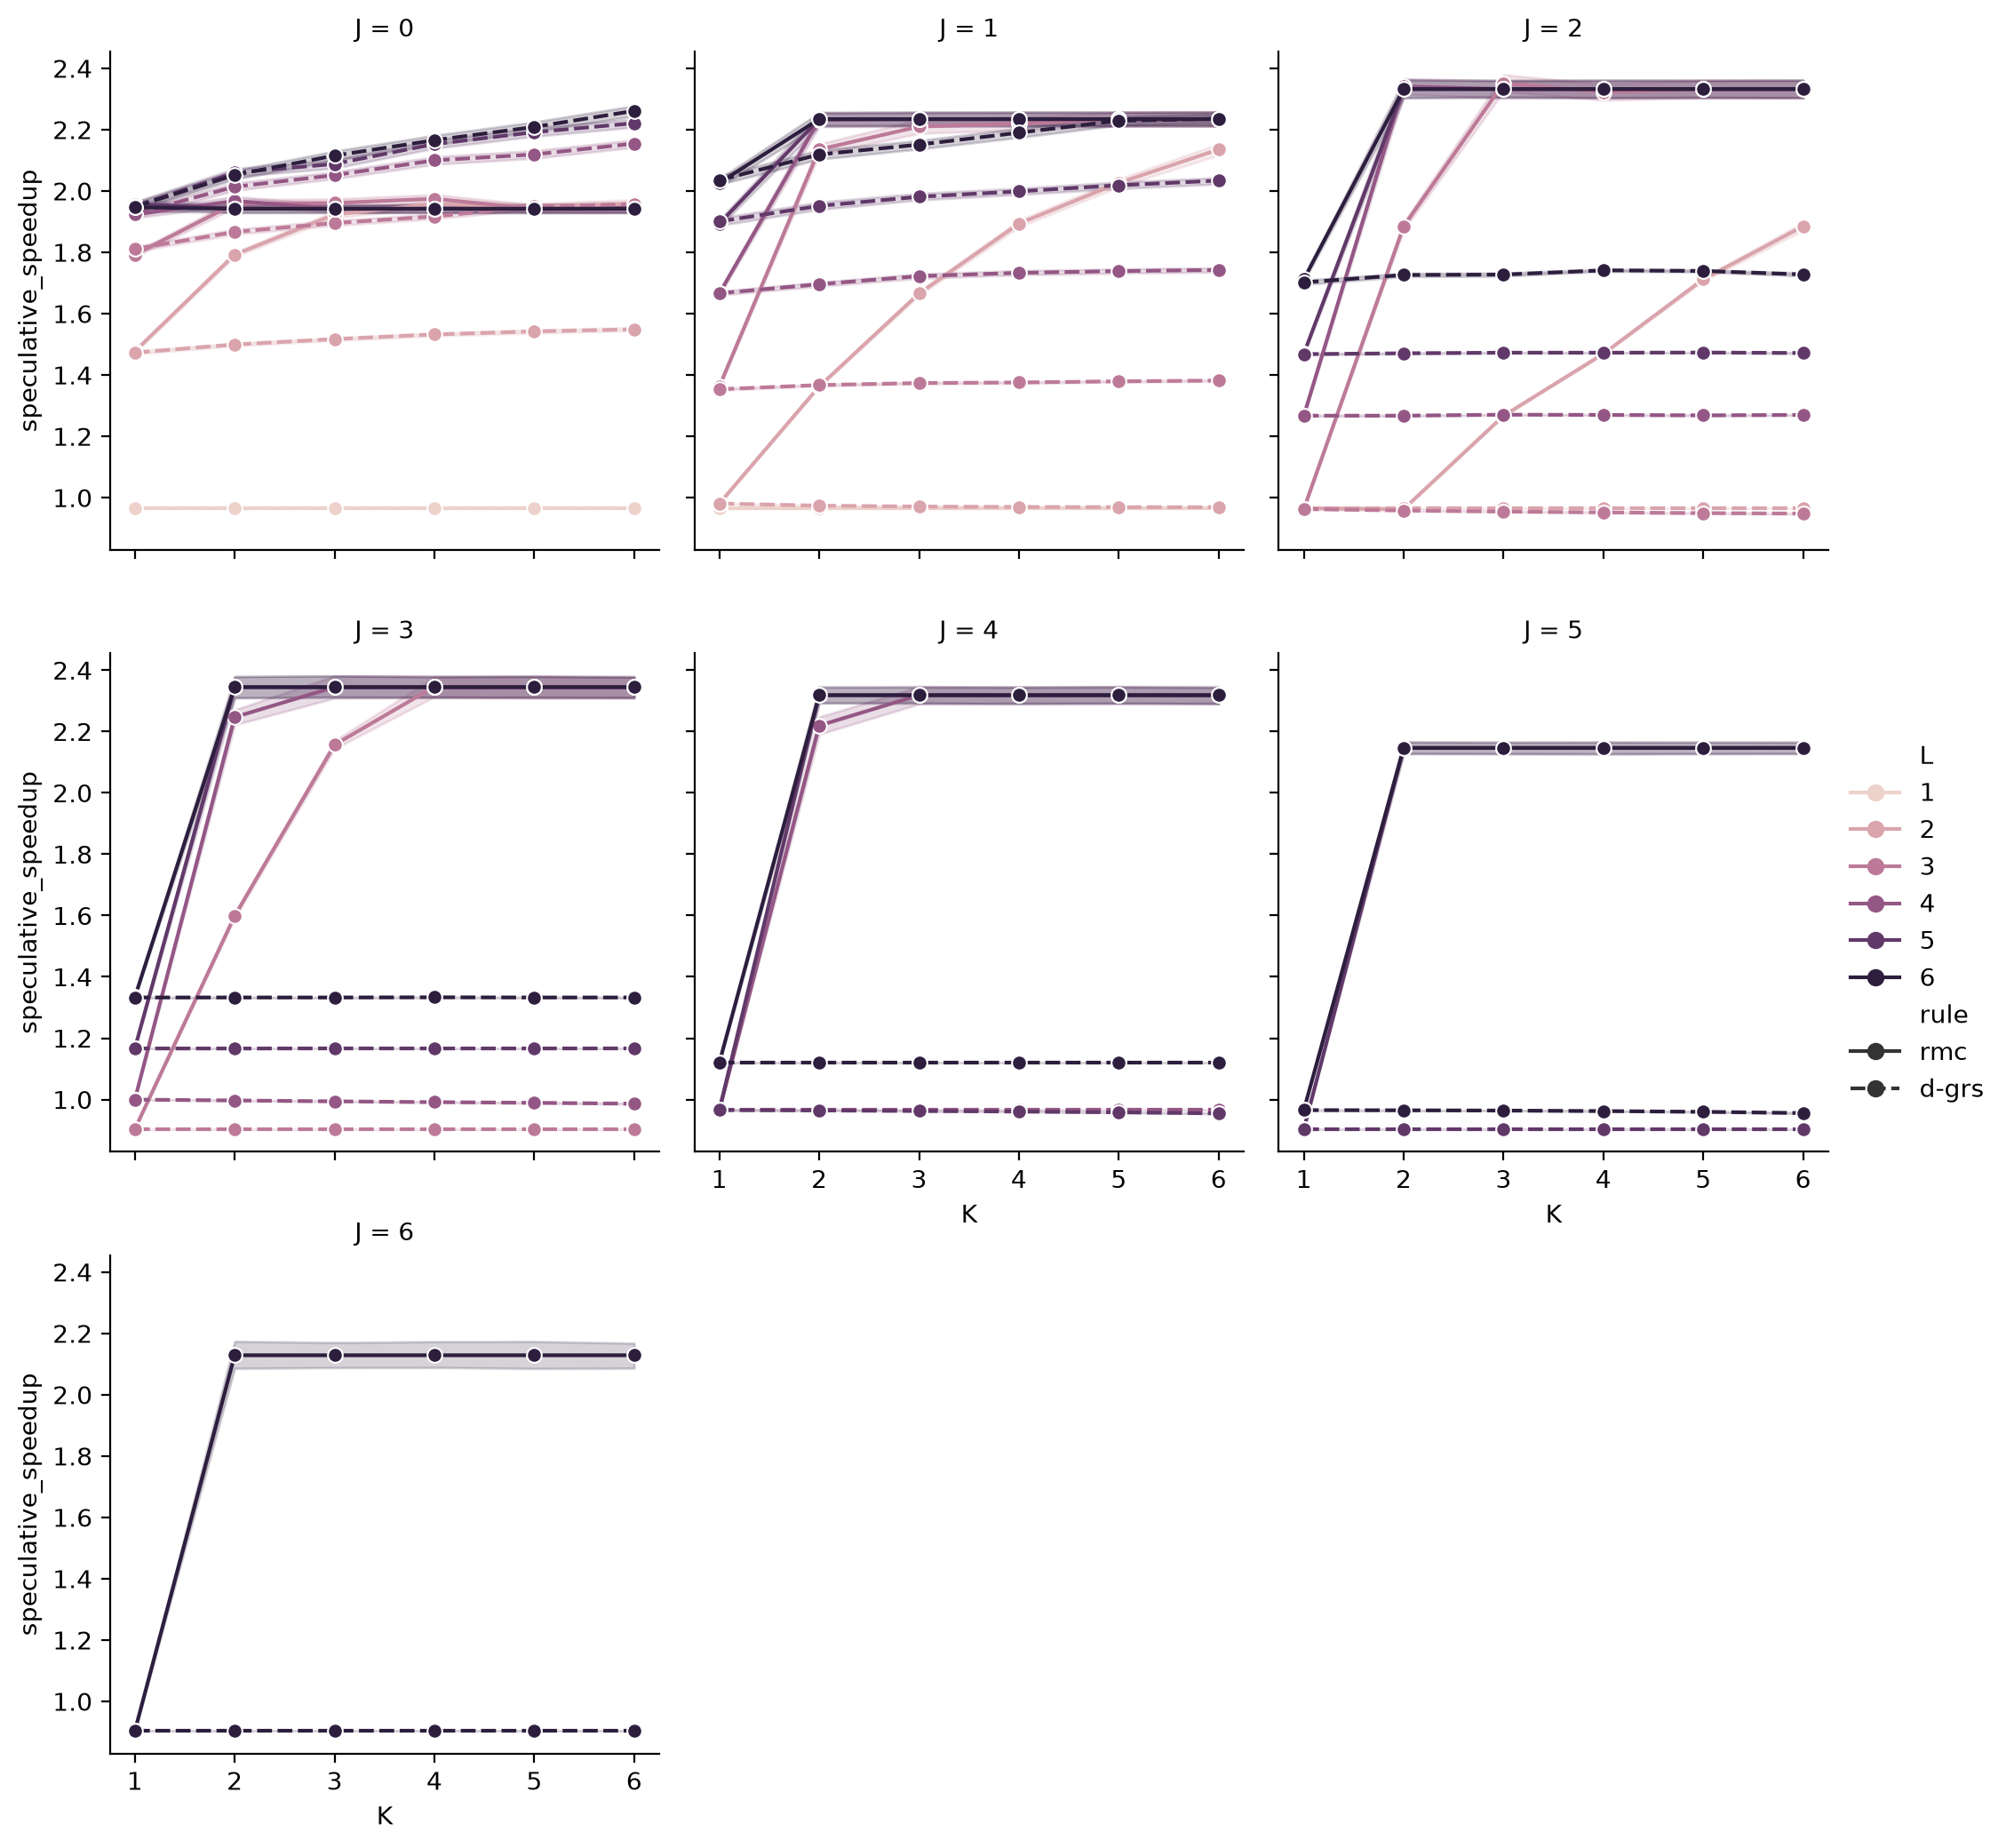

In [29]:
g=sns.relplot(
    data=gm_trajectories, 
    x="K", 
    y="speculative_speedup", 
    hue="L", 
    #row="J",
    col_wrap=3,
    col="J",
    style="rule",
    marker="o",
    kind="line",
    height=3.5,
)


In [ ]:
gm_trajectories["rounds"]

0        28
1        28
2        28
3        28
4        28
         ..
40313     5
40314     2
40315     5
40316     2
40317     5
Name: rounds, Length: 40318, dtype: int64

In [11]:
gm_trajectories.columns

Index(['source_run', 'trajectory_id', 'eps', 'rule', 'K', 'L', 'J',
       'replicate', 'match', 'evaluate_leaves', 'B',
       'allocated_verification_budget', 'actual_proposal_budget',
       'verification_budget', 'chain_depth', 'dimension', 'num_steps',
       'total_steps', 'deterministic_steps', 'rounds', 'verified_levels',
       'accepted_depth', 'rejected_rounds', 'acceptance_rate',
       'mean_committed', 'max_committed', 'drafted_states',
       'proposals_examined', 'mean_proposals_examined',
       'proposal_target_calls', 'proposal_target_states_evaluated',
       'refinement_target_calls', 'refinement_target_states_evaluated',
       'verification_target_calls', 'verification_target_states_evaluated',
       'verification_target_means_reused', 'target_calls',
       'target_states_evaluated', 'speculative_speedup',
       'effective_total_target_calls', 'end_to_end_speedup', 'initial_l2',
       'initial_mean', 'initial_std', 'sample_l2', 'sample_mean', 'sample_std',
  

In [18]:
gm_trajectories.num_steps/gm_trajectories.target_calls

0        0.965517
1        0.965517
2        0.965517
3        0.965517
4        0.965517
           ...   
40313    0.965517
40314    2.153846
40315    0.965517
40316    2.153846
40317    0.965517
Length: 40318, dtype: float64

0        28
1        28
2        28
3        28
4        28
         ..
40313    28
40314    28
40315    28
40316    28
40317    28
Name: num_steps, Length: 40318, dtype: int64

In [14]:
gm_trajectories.speculative_speedup

0        0.965517
1        0.965517
2        0.965517
3        0.965517
4        0.965517
           ...   
40313    0.965517
40314    2.153846
40315    0.965517
40316    2.153846
40317    0.965517
Name: speculative_speedup, Length: 40318, dtype: float64